# =================================================================== (Sparse Reward)
# **Arquitectura 1 Alternate: FeUdal Networks — Protocol 3 Fases Seqüencial**
# ===================================================================

**Objectiu**: Implementar agent HRL amb protocol 3 fases seqüencial (Manager→Worker→Alternat).

Aquest notebook implementa l'arquitectura FeudalAgent amb protocol 3 fases, variant del notebook base `04_hrl_agent.ipynb`.

**Arquitectura**: FC-only (sense recurrència), net_arch=`[64, 32, 32]`, `Z_DIM=32`, `G_DIM=32`, `k=8`.

## Característiques clau:

**Perception** (compartit):
- FC 71→64 (tanh)
- FC 64→32 (tanh)
- FC 32→32 (tanh)
- Output: z ∈ ℝ^32

**Manager**:
- Policy: FC 32→64→32→32 + goal_head 32→32 (linear) + L2-norm → g ∈ ℝ^32
- Value: FC 32→64→32→32→1 (V^M)

**Worker**:
- **Policy multiplicativa** (entrada: z únicament):
  - z → FC 32→64→32→32→32 → reshape → U ∈ ℝ^(4×8)
  - g → φ (FC 32→8, no bias) → w ∈ ℝ^8
  - π = SoftMax(U·w)
- Value: Concat(z, g) → FC 64→64→32→32→1 (V^D)

**Total params**: ~33,218  (Perception: 7,744 · Manager: 11,585 · Worker: 13,889)

In [11]:
# =============================================================================
# CEL·LA 1 — IMPORTS
# =============================================================================

import json
import math
import os as _os
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import polars as pl
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Dict, List, Tuple
from codecarbon import EmissionsTracker
from torch.distributions import Categorical, Normal
from torch.utils.tensorboard import SummaryWriter
from tqdm.auto import tqdm

# ── SB3: RolloutBuffer i callbacks (NO la classe PPO) ─────────────────────────────
# RolloutBuffer: infraestructura de referència; HierarchicalRolloutBuffer
# l'estén per a l'arquitectura FeUdal dual (Worker pas a pas, Manager cada c).
from stable_baselines3.common.buffers import RolloutBuffer  # noqa: F401
from stable_baselines3.common.callbacks import BaseCallback

# ── Project ──────────────────────────────────────────────────────────────────────
from src.data.manager import DataManager
from src.rl.envs.crypto_market_env_consolidated_reward import (
    CryptoMarketEnvConsolidatedReward, INITIAL_BALANCE, MAX_EPISODE_STEPS, MIN_EPISODE_STEPS,
     LOG_COLS,
    HOLD_PENALTY, DD_THRESHOLD, DD_PENALTY, OPEN_POSITION_PENALTY, steps_per_4h_for,
)
from src.rl.metrics import compute_sharpe, compute_max_drawdown
from src.rl.model_summary import model_summary
from src.rl.utils import narrow, narrow_int, fee_curriculum_factor
from src.rl.visualization import plot_optuna_search, plot_training_curves, plot_walk_forward

# Pre-training support
from src.rl.training.pretrain_hrl import (
    PreTrainingConfig, SyntheticPhaseConfig, pretrain_and_train_hrl
)

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
print('Imports OK')


Imports OK


In [12]:
# =============================================================================
# CEL·LA 2 — CONFIGURACIÓ: SEED, DEVICE, PATHS
# =============================================================================

# Reproducibilitat
SEED = 42

# Protocol 3 Fases
PH1_TIMESTEPS = 200_000      # Fase 1: Manager bootstrap
PH2_TIMESTEPS = 200_000      # Fase 2: Worker bootstrap
N_ALT_CYCLES = 20            # Fase 3: Nombre de cycles alternats
CYCLE_TIMESTEPS = 100_000    # Fase 3: Timesteps per cycle
ALPHA_DECAY_H = 3.0          # Alpha decay half-life (cycles) — half-life 3-5 cicles
ALPHA_DECAY_0 = 1.0          # Alpha inicial (no tuneable)
ALIGN_COEF = 0.1             # Manager alignment loss coefficient

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# CWD
_cwd = Path.cwd()
if not (_cwd / "data" / "processed").exists():
    _root = _cwd.parents[1]
    if (_root / "data" / "processed").exists():
        _os.chdir(_root)
        print(f"CWD -> {Path.cwd()}")

# Paths
CHECKPOINTS    = Path("checkpoints_sparse"); CHECKPOINTS.mkdir(exist_ok=True)
RESULTS        = Path("results_sparse") / "05s_hrl_FeUdal_agent_relu_N"; RESULTS.mkdir(parents=True, exist_ok=True)
RUNS_DIR       = RESULTS / "runs"; RUNS_DIR.mkdir(parents=True, exist_ok=True)
CODECARBON_DIR = RESULTS / "codecarbon"; CODECARBON_DIR.mkdir(parents=True, exist_ok=True)
HRL_CKPT_DIR       = CHECKPOINTS / "hrl_sparse_feudal_agent_relu_N"; HRL_CKPT_DIR.mkdir(parents=True, exist_ok=True)
OPTUNA_STORAGE_DIR = RESULTS / "optuna_db"; OPTUNA_STORAGE_DIR.mkdir(parents=True, exist_ok=True)

# Identificador unic del notebook (per study_name Optuna)
NB_TAG = "sparse_relu"

# Fitxers de persistencia JSON
OPTUNA_HRL_P1_JSON    = RESULTS / "optuna_hrl_p1_best_params.json"
OPTUNA_HRL_P2_JSON    = RESULTS / "optuna_hrl_p2_best_params.json"
OPTUNA_HRL_FINAL_JSON = RESULTS / "optuna_hrl_final_best_params.json"

# Timeframe i DataManager
TIMEFRAME    = "60m"
PROJECT      = "nb05s_hrl_feudal"
dm           = DataManager(interval=TIMEFRAME, project_root=Path("."))
FEATURE_COLS = dm.features
N_FEATURES   = len(FEATURE_COLS)


# Fixed Hyperparameters (no tuneable)
FIXED_HP = {
    'vf_coef': 0.5,
    'max_grad_norm': 0.5,
    'manager_max_grad_norm': 5.0,
    'reward_scale': 0.5,
    'weight_decay': 0.0,
    'std_max': 0.0,
    'batch_size': 256,
    'n_epochs': 10,
    'clip_range': 0.2,
}


# ── Arquitectura HRL FeUdal (paper FuN, tanh) ────────────────────────
# Perception [64]       -> z(64)    obs->64(tanh)->64(linear)
# fMspace    [32]       -> St(32)   z->32(tanh)->32(linear)
# fMrnn      [32,32]    -> g(32)    St->32->32->32(linear)
# fWrnn      [32,32,32] -> U(AxK)   z->32->32->32->A*K(linear)
# phi        32->8      -> w(8)     linear, sense bias
# value M/W  [32]       -> 1        V^M=V^D: z->32(tanh)->1 (paper)
Z_DIM = 64                          # Perception output
G_DIM = 32                          # Goal/St dimension (s_t)
K_DIM = 8                           # phi output (k del paper)
PERCEPTION_HIDDEN = [128]                # Perception: obs->128(tanh)->64(linear)=z
FMSPACE_HIDDEN    = [32]            # fMspace: z->32(tanh)->32(linear)=St
FMRNN_HIDDEN      = [32, 32]        # fMrnn: LSTM(32->32)=g  (llista ignorada, hidden=G_DIM)
FWRNN_HIDDEN      = [32, 32, 32]    # fWpre: z->32(tanh)->32(linear); fWrnn: LSTM(32->A*K)
VALUE_HIDDEN      = [32]            # Value V^M=V^D: z->32(tanh)->1
MANAGER_HIDDEN    = FMSPACE_HIDDEN  # alias per FeUdalAgent
WORKER_HIDDEN     = FWRNN_HIDDEN    # alias per FeUdalAgent

# Hiperparàmetres d'entrenament
TUNE_TIMESTEPS    = 2_000_000
N_TRIALS          = 30
N_STARTUP         = 15
N_TRIALS_REFINE   = 20
MIN_POSITION_FRAC = 0.30
PRUNE_WARMUP_FRAC = 0.40
FINAL_TIMESTEPS   = 3_000_000
EVAL_FREQ         = 50_000
N_EVAL_EPS        = 10

# Curriculum learning de comissions
FEE_WARMUP_FRAC   = 0.40
FEE_RAMP_END_FRAC = 0.60

# Alpha curriculum
ALPHA_WARMUP_FRAC   = 0.4
ALPHA_RAMP_END_FRAC = 0.6
ALPHA_START         = 0.0

# Metrica objectiu Optuna
OPTUNA_OBJECTIVE  = 'best_return'
N_EVAL_EPS_TUNE   = 5

# Custom prune
CUSTOM_PRUNE_WARMUP       = 1_750_000
CUSTOM_PRUNE_MIN_RET      = +0.5
CUSTOM_PRUNE_CHECK_POLICY = False
CUSTOM_PRUNE_MAX_ENTROPY  = 1.37
CUSTOM_PRUNE_MIN_KL       = 5e-4

# Longitud d'episodi variable
VARIABLE_LENGTH = True
EP_STEPS_MIN    = MIN_EPISODE_STEPS
EP_STEPS_MAX    = 6_048
EP_STEPS_EVAL   = MAX_EPISODE_STEPS

print(f"Features:    {N_FEATURES}")
print(f"Reward:      SPARSE — reward consolidat al CLOSE")
print(f"Arquitectura FuN: Z={Z_DIM} G={G_DIM} K={K_DIM}")
print(f"  Perception: {PERCEPTION_HIDDEN} -> z({Z_DIM})")
print(f"  fMspace:    {FMSPACE_HIDDEN + [G_DIM]} -> St({G_DIM})")
print(f"  fMrnn:      {FMRNN_HIDDEN + [G_DIM]} -> g({G_DIM})")
print(f"  fWrnn:      {FWRNN_HIDDEN + [32]} -> U(Ax{K_DIM})")
print(f"  phi:        {G_DIM} -> w({K_DIM})")
print(f"Tune: {TUNE_TIMESTEPS:,} ts / {N_TRIALS} trials  |  Final: {FINAL_TIMESTEPS:,} ts")



Device: cuda
Features:    65
Reward:      SPARSE — reward consolidat al CLOSE
Arquitectura FuN: Z=64 G=32 K=8
  Perception: [128] -> z(64)
  fMspace:    [32, 32] -> St(32)
  fMrnn:      [32, 32, 32] -> g(32)
  fWrnn:      [32, 32, 32, 32] -> U(Ax8)
  phi:        32 -> w(8)
Tune: 2,000,000 ts / 30 trials  |  Final: 3,000,000 ts


In [13]:
# ── Pre-training configuration ────────────────────────────────────────────────
PRE_TRAINING = False  # Set to True to enable synthetic pre-training
PRE_TRAIN_PHASE1_STEPS = 100_000   # Fixed frequency sine
PRE_TRAIN_PHASE2_STEPS = 100_000   # Chirp (frequency sweep)
PRE_TRAIN_PHASE3_STEPS = 100_000  # Fractal multi-frequency

# ── SMOKE TEST MODE ────────────────────────────────────────────────────────────
# Set to True for quick validation (2 TPE trials, 500 steps each, 1k pre-train)
# Set to False for full optimization runs
SMOKE = False

if SMOKE:
    print("\n" + "="*80)
    print("WARNING: SMOKE TEST MODE ENABLED")
    print("Quick validation run: 2 TPE trials, 500 timesteps, minimal pre-training")
    print("Set SMOKE=False for full optimization")
    print("="*80 + "\n")
    
    # Override training parameters for smoke test
    TUNE_TIMESTEPS = 500
    N_TRIALS = 2
    N_TRIALS_REFINE = 2  # Skip CMA in smoke mode
    FINAL_TIMESTEPS = 1_000
    
    # Override pre-training steps
    PRE_TRAIN_PHASE1_STEPS = 1_000
    PRE_TRAIN_PHASE2_STEPS = 1_000
    PRE_TRAIN_PHASE3_STEPS = 2_000
else:
    # Normal configuration (defined in previous cells or defaults)
    TUNE_TIMESTEPS = TUNE_TIMESTEPS if 'TUNE_TIMESTEPS' in globals() else 100_000
    N_TRIALS = N_TRIALS if 'N_TRIALS' in globals() else 30
    N_TRIALS_REFINE = N_TRIALS_REFINE if 'N_TRIALS_REFINE' in globals() else 20
    FINAL_TIMESTEPS = FINAL_TIMESTEPS if 'FINAL_TIMESTEPS' in globals() else 500_000


In [14]:
# =============================================================================
# CEL·LA 3 — CÀRREGA DE DADES
# =============================================================================

df_train, df_val, df_test = dm.load_all()

# ── Load synthetic data if pre-training enabled ───────────────────────────────
if PRE_TRAINING:
    import polars as pl
    SYNTHETIC_DIR = Path("data/synthetic")
    df_synth_p1 = pl.read_parquet(SYNTHETIC_DIR / "phase1_fixed_freq.parquet")
    df_synth_p2 = pl.read_parquet(SYNTHETIC_DIR / "phase2_chirp.parquet")
    df_synth_p3 = pl.read_parquet(SYNTHETIC_DIR / "phase3_fractal.parquet")
    print(f"\nSynthetic data loaded:")
    print(f"  Phase 1: {len(df_synth_p1):,} steps (fixed freq)")
    print(f"  Phase 2: {len(df_synth_p2):,} steps (chirp)")
    print(f"  Phase 3: {len(df_synth_p3):,} steps (fractal)")
    print(f"  Total: {len(df_synth_p1) + len(df_synth_p2) + len(df_synth_p3):,} synthetic timesteps")
    print(f"\nPre-training schedule:")
    print(f"  Phase 1: {PRE_TRAIN_PHASE1_STEPS:,} training steps")
    print(f"  Phase 2: {PRE_TRAIN_PHASE2_STEPS:,} training steps")
    print(f"  Phase 3: {PRE_TRAIN_PHASE3_STEPS:,} training steps")
    print(f"  Real data: {TUNE_TIMESTEPS:,} + {FINAL_TIMESTEPS:,} steps\n")

print(f"Train: {len(df_train):>8,}  ({df_train['timestamp'].min()} → {df_train['timestamp'].max()})")
print(f"Val:   {len(df_val):>8,}  ({df_val['timestamp'].min()} → {df_val['timestamp'].max()})")
print(f"Test:  {len(df_test):>8,}  ({df_test['timestamp'].min()} → {df_test['timestamp'].max()})")


Train:   43,763  (2018-01-01 00:00:00 → 2022-12-31 23:00:00)
Val:      8,759  (2023-01-01 00:00:00 → 2023-12-31 23:00:00)
Test:    17,500  (2024-01-01 00:00:00 → 2025-12-31 00:00:00)


## 1. Entorn CryptoMarketEnvConsolidatedReward (importat de `src/`)

Entorn sparse: `src/rl/envs/crypto_market_env_consolidated_reward.py`.


In [15]:
# =============================================================================
# CEL·LA 4 — FACTORIA D'ENTORN + VERIFICACIÓ
# =============================================================================

def make_env_consolidated(df: pl.DataFrame, **kwargs) -> CryptoMarketEnvConsolidatedReward:
    """Factoria per crear l'entorn amb FEATURE_COLS. Reward: PnL-only (sparse — reward only on close)."""
    return CryptoMarketEnvConsolidatedReward(
        df=df,
        feature_cols=FEATURE_COLS,
        
        steps_per_4h=steps_per_4h_for(TIMEFRAME),
        
        **kwargs,
    )

_env = make_env_consolidated(df_train)
_obs, _info = _env.reset(seed=SEED)
OBS_DIM   = _env.observation_space.shape[0]
N_ACTIONS = _env.action_space.n
del _env

print(f'make_env_consolidated OK | OBS_DIM={OBS_DIM} ({N_FEATURES} features + {OBS_DIM - N_FEATURES} estat intern)')
print(f'N_ACTIONS={N_ACTIONS}  |  steps_per_4h={steps_per_4h_for(TIMEFRAME)}')


make_env_consolidated OK | OBS_DIM=71 (65 features + 6 estat intern)
N_ACTIONS=4  |  steps_per_4h=4


## 2. Arquitectura FeudalAgent (embut unificat)

### Principi de disseny

Xarxes FC amb `net_arch = [N_HIDDEN, N_HIDDEN//2] = [64, 32]`. La percepció projecta `obs_dim → N_HIDDEN → Z_DIM`:

| Xarxa | Entrada | Capes ocultes | Sortida |
|-------|---------|---------------|---------|
| Percepcio | obs_dim (71) | [64, 32] | z ∈ ℝ^32 |
| Manager π | z (32) | [64, 32, 32] | goal_head 32→32 + L2-norm → g ∈ ℝ^32 |
| Manager V | z (32) | [64, 32, 32] | value_head → 1 |
| Worker π (mult) | z (32) | [64, 32, 32] | action_embed 32→32 → U(4×8); g→φ(8)→w; π=SoftMax(U·w) |
| Worker V | Concat(z,g) (64) | [64, 32, 32] | value_head → 1 |

**Nota**: la branca policy del Worker rep **només z** (no concat); el goal entra exclusivament via φ.

### Init ortogonal (SB3 defaults)
- Backbones (capes ocultes): `gain = √2`
- action/goal head: `gain = 0.01`
- value heads: `gain = 1.0`


In [16]:
# ===================================================================
# CEL.LA 4 - PERCEPTION MODULE (compartit)
# ===================================================================

class PerceptionModule(nn.Module):
    """
    Modul de percepcio compartit entre Manager i Worker.

    Arquitectura (paper FuN, tanh):
    obs_dim -> hidden (tanh) -> z_dim (linear) = z
    """

    def __init__(self, obs_dim: int, z_dim: int, hidden: list):
        super().__init__()
        dims = [obs_dim] + hidden + [z_dim]
        layers = []
        for i in range(len(dims) - 2):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(dims[-2], dims[-1]))
        self.net = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


# Test
perception = PerceptionModule(OBS_DIM, Z_DIM, PERCEPTION_HIDDEN).to(DEVICE)
model_summary(perception, input_size=(1, OBS_DIM))
test_obs = torch.randn(32, OBS_DIM).to(DEVICE)
test_z = perception(test_obs)
print(f"PerceptionModule OK: {test_obs.shape} -> {test_z.shape}")


Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
PerceptionModule (PerceptionModule)      [1, 71]              [1, 64]              --                   True
├─Sequential (net)                       [1, 71]              [1, 64]              --                   True
│    └─Linear (0)                        [1, 71]              [1, 128]             9,216                True
│    └─Tanh (1)                          [1, 128]             [1, 128]             --                   --
│    └─Linear (2)                        [1, 128]             [1, 64]              8,256                True
Total params: 17,472
Trainable params: 17,472
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.02
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.07
Estimated Total Size (MB): 0.07
PerceptionModule OK: torch.Size([32, 71]) -> torch.Size([32, 64])


In [17]:
# ===================================================================
# CEL.LA 5 - MANAGER MODULE
# ===================================================================

class ManagerModule(nn.Module):
    """
    Manager: genera goals g in R^G_DIM i estima valor V^M.

    fMspace (z -> St):  f^Mspace del paper (z->32(tanh)->32(linear))
    fMrnn   (St -> g):  f^Mrnn sense recurrencia (St->32->32->32(linear))
    Value   (z -> V^M): V^M(xt) del paper eq.5 (z->32(tanh)->1)
    """

    def __init__(self, z_dim: int, g_dim: int, fmspace_hidden: list,
                 fmrnn_hidden: list, value_hidden: list):
        super().__init__()

        # fMspace: z -> St  (64->32 Tanh)
        self.fMspace = nn.Sequential(
            nn.Linear(z_dim, g_dim), nn.Tanh(),
        )

        # fMrnn: St -> g via LSTM (1 capa, hidden=g_dim, paper FuN)
        self.fMrnn = nn.LSTM(input_size=g_dim, hidden_size=g_dim,
                             num_layers=1, batch_first=True)

        # Value head: V^M(xt) = z -> 1 (paper eq. 5)
        value_dims = [z_dim] + value_hidden + [1]
        layers = []
        for i in range(len(value_dims) - 2):
            layers.append(nn.Linear(value_dims[i], value_dims[i+1]))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(value_dims[-2], value_dims[-1]))
        self.value_net = nn.Sequential(*layers)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, z: torch.Tensor, hx=None) -> dict:
        st                = self.fMspace(z)                      # (B, g_dim)
        g_seq, (h_n, c_n) = self.fMrnn(st.unsqueeze(1), hx)     # (B, 1, g_dim)
        g_hat             = g_seq.squeeze(1)                     # (B, g_dim)
        goal              = F.normalize(g_hat, dim=-1)
        value             = self.value_net(z)
        return {"goal": goal, "value": value, "st": st, "hx": (h_n, c_n)}


# Test
manager = ManagerModule(
    z_dim=Z_DIM, g_dim=G_DIM,
    fmspace_hidden=FMSPACE_HIDDEN,
    fmrnn_hidden=FMRNN_HIDDEN,
    value_hidden=VALUE_HIDDEN,
).to(DEVICE)

model_summary(manager, input_size=(1, Z_DIM))
test_z = torch.randn(32, Z_DIM).to(DEVICE)
manager_out = manager(test_z)
goal_norms  = manager_out['goal'].norm(dim=-1)
print(f"ManagerModule OK")
print(f"  St:   {manager_out['st'].shape}")
print(f"  Goal: {manager_out['goal'].shape}  norm(min={goal_norms.min():.4f} max={goal_norms.max():.4f})")
print(f"  Value:   {manager_out['value'].shape}")


Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
ManagerModule (ManagerModule)            [1, 64]              [1, 1, 32]           --                   True
├─Sequential (fMspace)                   [1, 64]              [1, 32]              --                   True
│    └─Linear (0)                        [1, 64]              [1, 32]              2,080                True
│    └─Tanh (1)                          [1, 32]              [1, 32]              --                   --
├─LSTM (fMrnn)                           [1, 1, 32]           [1, 1, 32]           8,448                True
├─Sequential (value_net)                 [1, 64]              [1, 1]               --                   True
│    └─Linear (0)                        [1, 64]              [1, 32]              2,080                True
│    └─Tanh (1)                          [1, 32]              [1, 32]              --                   --
│    └─Linear (2) 

In [18]:
# ===================================================================
# CEL.LA 6 - WORKER MODULE (Multiplicativa U*w, paper FuN eq. 3)
# ===================================================================

class WorkerModule(nn.Module):
    """
    Worker: selecciona accions via multiplicacio U*w (FuN).

    fWpre (z -> h):  z->32(tanh)->32(linear)
    fWrnn (h -> U):  LSTM(32->A*K), reshape (A,K) = U
    phi   (g -> w):  g->k (linear, sense bias), paper phi
    logits = U * w -> politica
    Value: V^D(xt) = z -> 1 (paper eq. 7, sense condicionament al goal)
    """
    def __init__(self, z_dim: int, g_dim: int, k_dim: int, n_actions: int,
                 fwrnn_hidden: list, value_hidden: list):
        super().__init__()
        self.action_dim = n_actions
        self.k_dim = k_dim

        # fWpre: z -> lstm_input  (64->32 Tanh -> 32 linear)
        h = fwrnn_hidden[0]  # 32
        self.fWpre = nn.Sequential(
            nn.Linear(z_dim, h), nn.Tanh(),
        )
        # fWrnn: LSTM(input=32, hidden=A*K)
        self.fWrnn = nn.LSTM(input_size=int(h), hidden_size=int(n_actions * k_dim),
                             num_layers=1, batch_first=True)

        # phi: g -> w (sense bias, alineat amb paper FuN)
        self.phi = nn.Linear(g_dim, k_dim, bias=False)

        # Value: V^D(xt) = z -> 1 (paper eq. 7)
        value_dims = [z_dim] + value_hidden + [1]
        layers = []
        for i in range(len(value_dims) - 2):
            layers.append(nn.Linear(value_dims[i], value_dims[i+1]))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(value_dims[-2], value_dims[-1]))
        self.value_net = nn.Sequential(*layers)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, z: torch.Tensor, goal: torch.Tensor, hx=None) -> tuple:
        B                 = z.size(0)
        pre               = self.fWpre(z)                         # (B, 32)
        U_seq, (h_n, c_n) = self.fWrnn(pre.unsqueeze(1), hx)     # (B, 1, A*K)
        U_flat            = U_seq.squeeze(1)                      # (B, A*K)
        U                 = U_flat.view(B, self.action_dim, self.k_dim)
        w                 = self.phi(goal)
        logits            = torch.bmm(U, w.unsqueeze(-1)).squeeze(-1)
        value             = self.value_net(z)
        return logits, value, (h_n, c_n)


# Test
worker = WorkerModule(
    z_dim=Z_DIM, g_dim=G_DIM, k_dim=K_DIM, n_actions=N_ACTIONS,
    fwrnn_hidden=FWRNN_HIDDEN,
    value_hidden=VALUE_HIDDEN,
).to(DEVICE)

model_summary(worker, input_data=[
    torch.zeros(1, Z_DIM, device=DEVICE),
    torch.zeros(1, G_DIM, device=DEVICE),
])
test_z    = torch.randn(32, Z_DIM).to(DEVICE)
test_goal = torch.randn(32, G_DIM).to(DEVICE)
logits, value, hx_w = worker(test_z, test_goal)
print(f"WorkerModule OK  logits:{logits.shape}  value:{value.shape}  hx:({hx_w[0].shape},{hx_w[1].shape})")


Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
WorkerModule (WorkerModule)              [1, 64]              [1, 4]               --                   True
├─Sequential (fWpre)                     [1, 64]              [1, 32]              --                   True
│    └─Linear (0)                        [1, 64]              [1, 32]              2,080                True
│    └─Tanh (1)                          [1, 32]              [1, 32]              --                   --
├─LSTM (fWrnn)                           [1, 1, 32]           [1, 1, 32]           8,448                True
├─Linear (phi)                           [1, 32]              [1, 8]               256                  True
├─Sequential (value_net)                 [1, 64]              [1, 1]               --                   True
│    └─Linear (0)                        [1, 64]              [1, 32]              2,080                True
│    └─Tanh (1) 

In [19]:
# ===================================================================
# CEL.LA 7 - AGENT HRL FEUDAL (Integracio completa)
# ===================================================================

class FeUdalAgent(nn.Module):
    """
    Agent HRL FeUdal (FuN, Vezhnevets 2017) sense recurrencia.

    Flux:
      obs -> Perception -> z
      z   -> fMspace -> St   (representacio interna Manager)
      St  -> fMrnn   -> g    (goal normalitzat)
      z   -> fWrnn   -> U    (embedding accions)
      g   -> phi     -> w    (projeccio goal)
      U*w -> logits  -> accio

    r_int = cos_sim(St(z_{t+c}) - St(z_t), g_{t-c})  (FuN eq. 9)
    """

    def __init__(self, obs_dim: int, action_dim: int, z_dim: int, g_dim: int,
                 k_dim: int, manager_hidden: list, worker_hidden: list,
                 fmrnn_hidden: list = None, value_hidden: list = None,
                 perception_hidden: list = None):
        super().__init__()
        self.obs_dim    = obs_dim
        self.action_dim = action_dim
        self.g_dim      = g_dim

        _perc_h  = perception_hidden if perception_hidden is not None else [64, 64]
        _fmrnn_h = fmrnn_hidden      if fmrnn_hidden      is not None else [64, 32, 32]
        _val_h   = value_hidden      if value_hidden       is not None else [64, 32]

        self.perception = PerceptionModule(obs_dim, z_dim, _perc_h)
        self.manager    = ManagerModule(
            z_dim=z_dim, g_dim=g_dim,
            fmspace_hidden=manager_hidden,
            fmrnn_hidden=_fmrnn_h,
            value_hidden=_val_h,
        )
        self.worker = WorkerModule(
            z_dim=z_dim, g_dim=g_dim, k_dim=k_dim, n_actions=action_dim,
            fwrnn_hidden=worker_hidden,
            value_hidden=_val_h,
        )

    def forward(self, obs: torch.Tensor) -> dict:
        z           = self.perception(obs)
        manager_out = self.manager(z)
        goal        = manager_out["goal"]
        worker_logits, worker_value, _ = self.worker(z, goal.detach())
        return {
            "logits":        worker_logits,
            "worker_value":  worker_value,
            "goal":          goal,
            "manager_value": manager_out["value"],
            "st":            manager_out["st"],
            "z":             z,
        }

    def select_action(self, obs: torch.Tensor, deterministic: bool = False):
        with torch.no_grad():
            outputs = self.forward(obs.unsqueeze(0))
            probs   = F.softmax(outputs["logits"], dim=-1)
            if deterministic:
                action = torch.argmax(probs, dim=-1).item()
            else:
                action = Categorical(probs).sample().item()
            return action, outputs

    def perceive(self, obs: torch.Tensor) -> torch.Tensor:
        return self.perception(obs)

    def phi_z(self, z: torch.Tensor) -> torch.Tensor:
        """St = fMspace(z): crida directa, sense LSTM (per r_int)."""
        with torch.no_grad():
            return self.manager.fMspace(z)

    def manager_forward(self, z: torch.Tensor, hx=None):
        out = self.manager(z, hx=hx)
        return out["goal"], out["value"], out["hx"]

    def manager_sample(self, z: torch.Tensor, hx=None, std_max: float = 0.0):
        # TPG: Manager deterministic, sense distribucio Normal
        out = self.manager(z, hx=hx)
        g   = out["goal"]
        val = out["value"]
        dummy_lp = torch.zeros(g.size(0), 1, device=g.device)
        return g, g, dummy_lp, val, g, out["hx"]

    def worker_forward(self, z: torch.Tensor, goal: torch.Tensor, hx=None):
        logits, value, hx_new = self.worker(z, goal.detach(), hx=hx)
        return logits, value, hx_new

    def worker_sample(self, z: torch.Tensor, goal: torch.Tensor, hx=None):
        logits, val, hx_new = self.worker(z, goal.detach(), hx=hx)
        dist = Categorical(logits=logits)
        act  = dist.sample()
        lp   = dist.log_prob(act)
        return act, lp, logits, val, hx_new

    def predict_step(self, obs, step_ep: int, c: int, cur_goal,
                     device, deterministic: bool = True, mgr_hx=None, wkr_hx=None):
        obs_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad():
            z = self.perceive(obs_t)
            if cur_goal is None or step_ep % c == 0:
                goal_t, _, mgr_hx = self.manager_forward(z, hx=mgr_hx)
                cur_goal  = goal_t.squeeze(0).cpu().numpy()
            g_t = torch.tensor(cur_goal, dtype=torch.float32, device=device).unsqueeze(0)
            logits, _, wkr_hx = self.worker_forward(z, g_t, hx=wkr_hx)
            if deterministic:
                action = torch.argmax(logits, dim=-1).item()
            else:
                action = Categorical(logits=logits).sample().item()
        return action, cur_goal, mgr_hx, wkr_hx

    def freeze_manager(self):
        for p in self.manager.parameters():
            p.requires_grad = False

    def unfreeze_manager(self):
        for p in self.manager.parameters():
            p.requires_grad = True

    def init_manager_hidden(self, batch_size: int = 1, device=None):
        """Inicialitza hidden state LSTM Manager a zeros.

        Returns: (h, c) tensors shape (1, batch_size, g_dim).
        """
        dev = device or next(self.parameters()).device
        h = torch.zeros(1, batch_size, self.g_dim, device=dev)
        c = torch.zeros(1, batch_size, self.g_dim, device=dev)
        return h, c

    def init_worker_hidden(self, batch_size: int = 1, device=None):
        """Inicialitza hidden state LSTM Worker a zeros.

        Returns: (h, c) tensors shape (1, batch_size, n_actions*k_dim).
        """
        dev = device or next(self.parameters()).device
        size = self.worker.action_dim * self.worker.k_dim
        h = torch.zeros(1, batch_size, size, device=dev)
        c = torch.zeros(1, batch_size, size, device=dev)
        return h, c

    def freeze_worker(self):
        for p in self.worker.parameters():
            p.requires_grad = False

    def unfreeze_worker(self):
        for p in self.worker.parameters():
            p.requires_grad = True


agent = FeUdalAgent(
    obs_dim=OBS_DIM, action_dim=N_ACTIONS,
    z_dim=Z_DIM, g_dim=G_DIM, k_dim=K_DIM,
    manager_hidden=MANAGER_HIDDEN,
    worker_hidden=WORKER_HIDDEN,
    fmrnn_hidden=FMRNN_HIDDEN,
    value_hidden=VALUE_HIDDEN,
    perception_hidden=PERCEPTION_HIDDEN,
).to(DEVICE)

model_summary(agent, input_size=(1, OBS_DIM))
total_params     = sum(p.numel() for p in agent.parameters())
trainable_params = sum(p.numel() for p in agent.parameters() if p.requires_grad)
print(f"FeUdalAgent OK")
print(f"Total parametres:     {total_params:,}")
print(f"Trainable parametres: {trainable_params:,}")
print(f"  Perception: {sum(p.numel() for p in agent.perception.parameters()):,}")
print(f"  Manager:    {sum(p.numel() for p in agent.manager.parameters()):,}")
print(f"  Worker:     {sum(p.numel() for p in agent.worker.parameters()):,}")

# Verificacio 'No gradient': gradient Worker no ha d'arribar al Manager
_test_obs = torch.randn(2, OBS_DIM).to(DEVICE)
_out = agent.forward(_test_obs)
_loss = _out['logits'].sum() + _out['worker_value'].sum()
_loss.backward()
_mgr_grad = agent.manager.fMrnn.weight_ih_l0.grad
assert _mgr_grad is None or _mgr_grad.abs().max().item() == 0, \
    'ERROR: gradient del Worker ha arribat al Manager!'
agent.zero_grad()
print("Verificacio 'No gradient' Worker->Manager: OK")

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
FeUdalAgent (FeUdalAgent)                [1, 71]              [1, 64]              --                   True
├─PerceptionModule (perception)          [1, 71]              [1, 64]              --                   True
│    └─Sequential (net)                  [1, 71]              [1, 64]              --                   True
│    │    └─Linear (0)                   [1, 71]              [1, 128]             9,216                True
│    │    └─Tanh (1)                     [1, 128]             [1, 128]             --                   --
│    │    └─Linear (2)                   [1, 128]             [1, 64]              8,256                True
├─ManagerModule (manager)                [1, 64]              [1, 1, 32]           --                   True
│    └─Sequential (fMspace)              [1, 64]              [1, 32]              --                   True
│    │    └─Line

## 3. Infraestructura d'entrenament

- **HierarchicalRolloutBuffer**: buffer dual (Worker cada pas, Manager cada c passos)
- **ppo_update_worker / ppo_update_manager**: updates PPO separats per a cada nivell
- **compute_intrinsic_reward**: recompensa intrínseca FeUdal (cosine similarity)
- **evaluate_agent / walk_forward_eval_hrl**: avaluacio compatible amb FeudalAgent


In [20]:
# =============================================================================
# CEL·LA 6 — HierarchicalRolloutBuffer
# =============================================================================
# Buffer dual: Worker (n_steps pas a pas) + Manager (cada c passos).
# Reemplaca SB3 RolloutBuffer per a l'arquitectura FeUdal jeràrquica:
# gestiona dos fluxos temporals amb granularitats diferents i calcula GAE.
# =============================================================================

class HierarchicalRolloutBuffer:
    """Buffer dual (Worker pas a pas, Manager cada c passos)."""

    def __init__(self, n_steps: int, obs_dim: int, latent_dim: int,
                 goal_dim: int, c: int, device: 'torch.device | str'):
        self.n_steps    = n_steps
        self.obs_dim    = obs_dim
        self.latent_dim = latent_dim
        self.goal_dim   = goal_dim
        self.c          = c
        self.device     = device
        self.n_mgr_max  = 2 * n_steps + 4  # cota segura: episodis curts + fi d'episodi
        self.reset()

    def reset(self):
        self.w_obs   = np.zeros((self.n_steps, self.obs_dim),    dtype=np.float32)
        self.w_z     = np.zeros((self.n_steps, self.latent_dim), dtype=np.float32)
        self.w_goals = np.zeros((self.n_steps, self.goal_dim),   dtype=np.float32)
        self.w_acts  = np.zeros(self.n_steps,                    dtype=np.int64)
        self.w_rews  = np.zeros(self.n_steps,                    dtype=np.float32)
        self.w_vals  = np.zeros(self.n_steps,                    dtype=np.float32)
        self.w_lps   = np.zeros(self.n_steps,                    dtype=np.float32)
        self.w_dones = np.zeros(self.n_steps,                    dtype=np.float32)
        self.w_ptr   = 0
        self.m_z     = np.zeros((self.n_mgr_max, self.latent_dim), dtype=np.float32)
        self.m_graws = np.zeros((self.n_mgr_max, self.goal_dim),   dtype=np.float32)
        self.m_rews  = np.zeros(self.n_mgr_max,                    dtype=np.float32)
        self.m_vals  = np.zeros(self.n_mgr_max,                    dtype=np.float32)
        self.m_lps   = np.zeros(self.n_mgr_max,                    dtype=np.float32)
        self.m_dones = np.zeros(self.n_mgr_max,                    dtype=np.float32)
        self.m_ptr   = 0

    @staticmethod
    def _to_np(x):
        if isinstance(x, __import__('torch').Tensor):
            return x.detach().cpu().numpy().squeeze(0) if x.ndim > 1 else x.detach().cpu().numpy()
        return x

    def add_worker(self, obs, z, goal, act, rew, val, lp, done):
        i = self.w_ptr
        self.w_obs[i]   = self._to_np(obs)
        self.w_z[i]     = self._to_np(z)
        self.w_goals[i] = self._to_np(goal)
        self.w_acts[i]  = act
        self.w_rews[i]  = rew
        self.w_vals[i]  = val
        self.w_lps[i]   = lp
        self.w_dones[i] = done
        self.w_ptr     += 1

    def add_manager(self, z, g_raw, rew, val, lp, done):
        i = self.m_ptr
        self.m_z[i]     = self._to_np(z)
        self.m_graws[i] = self._to_np(g_raw)
        self.m_rews[i]  = rew
        self.m_vals[i]  = val
        self.m_lps[i]   = lp
        self.m_dones[i] = done
        self.m_ptr     += 1

    def compute_gae_worker(self, last_val: float, gamma: float, gae_lambda: float):
        n = self.w_ptr
        adv = np.zeros(n, dtype=np.float32)
        gae = 0.0
        for t in reversed(range(n)):
            nxt    = last_val if t == n - 1 else self.w_vals[t + 1]
            delta  = self.w_rews[t] + gamma * nxt * (1 - self.w_dones[t]) - self.w_vals[t]
            gae    = delta + gamma * gae_lambda * (1 - self.w_dones[t]) * gae
            adv[t] = gae
        return adv, adv + self.w_vals[:n]

    def compute_gae_manager(self, last_val: float, gamma_m: float, gae_lambda: float):
        n = self.m_ptr
        adv = np.zeros(n, dtype=np.float32)
        gae = 0.0
        for t in reversed(range(n)):
            nxt    = last_val if t == n - 1 else self.m_vals[t + 1]
            delta  = self.m_rews[t] + gamma_m * nxt * (1 - self.m_dones[t]) - self.m_vals[t]
            gae    = delta + gamma_m * gae_lambda * (1 - self.m_dones[t]) * gae
            adv[t] = gae
        return adv, adv + self.m_vals[:n]


    def get_manager_z_tensor(self) -> 'torch.Tensor':
        import torch
        return torch.tensor(self.m_z[:self.m_ptr], dtype=torch.float32, device=self.device)

    def get_manager_graws_tensor(self) -> 'torch.Tensor':
        import torch
        return torch.tensor(self.m_graws[:self.m_ptr], dtype=torch.float32, device=self.device)

    def get_manager_logprobs_tensor(self) -> 'torch.Tensor':
        import torch
        return torch.tensor(self.m_lps[:self.m_ptr], dtype=torch.float32, device=self.device)

    def get_manager_dones_tensor(self) -> 'torch.Tensor':
        import torch
        return torch.tensor(self.m_dones[:self.m_ptr], dtype=torch.float32, device=self.device)

print('HierarchicalRolloutBuffer OK')


HierarchicalRolloutBuffer OK


In [21]:
# =============================================================================
# CEL.LA 7 - ppo_update_worker / tpg_update_manager / _make_optimizers
# =============================================================================

def ppo_update_worker(
    agent, opt_perception, opt_worker,
    obs_t, goals_t, acts_t, rets_t, adv_t, lps_old_t,
    n_epochs, batch_size, clip_range, vf_coef, ent_coef, max_grad_norm,
    writer=None, global_step=None, phase='train',
) -> dict:
    """PPO update per al Worker (+ Percepcio compartida)."""
    n     = obs_t.shape[0]
    stats = {'policy_loss': [], 'value_loss': [], 'entropy': [], 'approx_kl': [],
             'grad_norm': [], 'clip_frac': [], 'explained_variance': []}
    
    # Accumuladors per logging de normes
    norm_Uw_list = []
    norm_U_list  = []
    norm_w_list  = []

    for _ in range(n_epochs):
        perm = torch.randperm(n, device=obs_t.device)
        for start in range(0, n, batch_size):
            b      = perm[start: start + batch_size]
            mb_adv = adv_t[b]
            if len(mb_adv) > 1:
                mb_adv = (mb_adv - mb_adv.mean()) / (mb_adv.std() + 1e-8)

            z_new  = agent.perceive(obs_t[b])
            g_det  = goals_t[b].detach()
            logits, new_val, _ = agent.worker_forward(z_new, g_det)
            dist   = Categorical(logits=logits)
            new_lp = dist.log_prob(acts_t[b])
            ent    = dist.entropy()

            # Logging de normes ||Uw|| vs ||worker_features||
            with torch.no_grad():
                pre    = agent.worker.fWpre(z_new)
                U_seq, _ = agent.worker.fWrnn(pre.unsqueeze(1))
                U_flat = U_seq.squeeze(1)
                U = U_flat.view(z_new.size(0), agent.worker.action_dim, agent.worker.k_dim)
                w = agent.worker.phi(g_det)
                Uw = torch.bmm(U, w.unsqueeze(-1)).squeeze(-1)
                norm_Uw = Uw.norm(dim=-1).mean().item()
                norm_U  = U.norm(dim=(-2, -1)).mean().item()
                norm_w  = w.norm(dim=-1).mean().item()
                norm_Uw_list.append(norm_Uw)
                norm_U_list.append(norm_U)
                norm_w_list.append(norm_w)

            ratio        = torch.exp(new_lp - lps_old_t[b])
            clip_frac_mb = ((ratio - 1).abs() > clip_range).float().mean().item()
            pg1   = -mb_adv * ratio
            pg2   = -mb_adv * ratio.clamp(1 - clip_range, 1 + clip_range)
            pl    = torch.max(pg1, pg2).mean()
            vl    = F.mse_loss(new_val, rets_t[b])
            el    = ent.mean()
            with torch.no_grad():
                ev_mb = (1 - (rets_t[b] - new_val.detach()).var() /
                         (rets_t[b].var() + 1e-8)).item()
            loss  = pl + vf_coef * vl - ent_coef * el

            opt_perception.zero_grad()
            opt_worker.zero_grad()
            loss.backward()
            gn_perc      = nn.utils.clip_grad_norm_(agent.perception.parameters(), max_grad_norm).item()
            gn_wkr       = nn.utils.clip_grad_norm_(agent.worker.parameters(), max_grad_norm).item()
            grad_norm_mb = max(gn_perc, gn_wkr)
            opt_perception.step()
            opt_worker.step()

            with torch.no_grad():
                kl = (lps_old_t[b] - new_lp).mean().item()
            stats['policy_loss'].append(pl.item())
            stats['value_loss'].append(vl.item())
            stats['entropy'].append(el.item())
            stats['approx_kl'].append(kl)
            stats['grad_norm'].append(grad_norm_mb)
            stats['clip_frac'].append(clip_frac_mb)
            stats['explained_variance'].append(ev_mb)

    # Logging de normes a TensorBoard
    result = {k: float(np.mean(v)) for k, v in stats.items()}
    if norm_Uw_list and writer is not None and global_step is not None:
        result["worker/norm_Uw"] = float(np.mean(norm_Uw_list))
        result["worker/norm_U"]  = float(np.mean(norm_U_list))
        result["worker/norm_w"]  = float(np.mean(norm_w_list))
        result["worker/norm_ratio"] = result["worker/norm_Uw"] / (result["worker/norm_U"] * result["worker/norm_w"] + 1e-8)
        writer.add_scalar(f"{phase}/worker/norm_Uw",    result["worker/norm_Uw"],    global_step)
        writer.add_scalar(f"{phase}/worker/norm_U",     result["worker/norm_U"],     global_step)
        writer.add_scalar(f"{phase}/worker/norm_w",     result["worker/norm_w"],     global_step)
        writer.add_scalar(f"{phase}/worker/norm_ratio", result["worker/norm_ratio"], global_step)
    
    return result


def tpg_update_manager(
    agent: "FeUdalAgent",
    optimizer: torch.optim.Optimizer,
    z_t: torch.Tensor,
    z_next_t: torch.Tensor,
    dones_t: torch.Tensor,
    returns_t: torch.Tensor,
    advantages_t: torch.Tensor,
    n_epochs: int,
    batch_size: int,
    vf_coef: float,
    max_grad_norm: float,
) -> dict:
    """Transition Policy Gradient (TPG) per al Manager (paper FuN eq. 5).

    ∇g_t = A^M_t · ∇_θ d_cos(s_{t+c} - s_t, g_t(θ))

    No hi ha distribució Normal, ratio d'importància ni clipping.
    delta_st detached (dependència de s en θ ignorada, eq.5 paper).
    """
    n = z_t.size(0)
    device = z_t.device
    if not isinstance(returns_t, torch.Tensor):
        returns_t    = torch.tensor(returns_t,    dtype=torch.float32, device=device)
    if not isinstance(advantages_t, torch.Tensor):
        advantages_t = torch.tensor(advantages_t, dtype=torch.float32, device=device)

    total_tpg_loss = total_value_loss = total_cos_sim = 0.0
    n_updates = 0

    for _ in range(n_epochs):
        perm = torch.randperm(n, device=device)
        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)
            idx = perm[start:end]

            z_b      = z_t[idx]
            z_next_b = z_next_t[idx]
            dones_b  = dones_t[idx]
            ret_b    = returns_t[idx]
            adv_b    = advantages_t[idx]

            if len(adv_b) > 1:
                adv_b = (adv_b - adv_b.mean()) / (adv_b.std() + 1e-8)

            # Forward Manager: gradient actiu sobre g
            out_b = agent.manager(z_b)
            g_b   = out_b['goal']
            val_b = out_b['value']

            # TPG: -(A^M * cos(delta_st_detached, g))
            mask = (dones_b < 0.5)
            if mask.sum() > 0:
                with torch.no_grad():
                    st_b      = agent.manager(z_b[mask])['st']
                    st_next_b = agent.manager(z_next_b[mask])['st']
                delta_st  = (st_next_b - st_b)
                delta_norm = delta_st / (delta_st.norm(dim=-1, keepdim=True) + 1e-8)
                g_norm     = g_b[mask] / (g_b[mask].norm(dim=-1, keepdim=True) + 1e-8)
                cos_sim    = (delta_norm * g_norm).sum(dim=-1)
                tpg_loss   = -(adv_b[mask] * cos_sim).mean()
                total_cos_sim += cos_sim.mean().item()
            else:
                tpg_loss = torch.tensor(0.0, device=device)

            value_loss = 0.5 * ((val_b.squeeze(-1) - ret_b) ** 2).mean()
            loss = tpg_loss + vf_coef * value_loss

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(agent.manager.parameters(), max_grad_norm)
            optimizer.step()

            total_tpg_loss   += tpg_loss.item()
            total_value_loss += value_loss.item()
            n_updates += 1

    n_u = max(n_updates, 1)
    return {
        "manager/tpg_loss":   total_tpg_loss   / n_u,
        "manager/value_loss": total_value_loss  / n_u,
        "manager/cos_sim":    total_cos_sim     / n_u,
    }

def _make_optimizers(agent, lr, manager_lr, weight_decay=0.0):
    """3 optimitzadors: perception, manager, worker.

    fMspace rep gradient de l'alignment loss via opt_manager.
    phi (Worker) rep gradient de la policy loss via opt_worker.
    """
    opt_p = torch.optim.Adam(agent.perception.parameters(),
                             lr=lr, eps=1e-5, weight_decay=weight_decay)
    opt_m = torch.optim.Adam(
        agent.manager.parameters(),
        lr=manager_lr, eps=1e-5, weight_decay=weight_decay,
    )
    opt_w = torch.optim.Adam(agent.worker.parameters(),
                             lr=lr, eps=1e-5, weight_decay=weight_decay)
    return opt_p, opt_m, opt_w


print('ppo_update_worker, tpg_update_manager, _make_optimizers definits')


ppo_update_worker, tpg_update_manager, _make_optimizers definits


In [22]:
# =============================================================================
# CEL·LA 8 — FUNCIONS AUXILIARS: r_int, evaluate_agent, walk_forward_eval_hrl
# =============================================================================

def compute_intrinsic_reward(
    phi_z_np: np.ndarray,
    phi_z_history: list,
    g_history: list,
    c: int,
) -> float:
    """r_int = (1/c) * sum_{i=1}^{c} d_cos(phi_z_np - phi_z_history[-i], g_history[-i]).

    Implementa FuN eq. 9: suma de c cosines entre el delta d'estat
    respecte cada un dels c punts anteriors i el seu goal corresponent.
    Retorna 0.0 si l'historial es insuficient (primeres c passes).
    """
    if len(phi_z_history) < c or len(g_history) < c:
        return 0.0
    total = 0.0
    for i in range(1, c + 1):
        delta_z = phi_z_np - phi_z_history[-i]
        g_prev  = g_history[-i]
        denom   = (np.linalg.norm(delta_z) + 1e-8) * (np.linalg.norm(g_prev) + 1e-8)
        total  += float(np.clip(np.dot(delta_z, g_prev) / denom, -1.0, 1.0))
    return total / c


def evaluate_agent(
    agent: FeUdalAgent,
    df: pl.DataFrame,
    n_episodes: int,
    device: 'torch.device | str',
    c: int,
    seed: int = SEED,
    deterministic: bool = True,
) -> dict:
    """
    Avaluacio de l'agent HRL sobre n_episodes episodis amb inici aleatori.
    Interficie identica a NB03b (evaluate_agent), adaptada per a FeudalAgent.
    """
    rng = np.random.default_rng(seed)
    env = make_env_consolidated(df)
    agent.eval()
    all_returns, all_equities, all_trades, all_pos_sides = [], [], [], []

    with torch.no_grad():
        for _ in range(n_episodes):
            obs, info = env.reset(seed=int(rng.integers(0, 1_000_000)))
            ep_eq = [info['equity']]; done = False; step_ep = 0; cur_goal = None; mgr_hx = None; wkr_hx = None

            while not done:
                action, cur_goal, mgr_hx, wkr_hx = agent.predict_step(
                    obs, step_ep, c, cur_goal, device, deterministic=deterministic,
                    mgr_hx=mgr_hx, wkr_hx=wkr_hx
                )
                obs, _, term, trunc, info = env.step(action)
                done = term or trunc
                ep_eq.append(info['equity'])
                all_pos_sides.append(info['pos_side'])
                step_ep += 1

            all_returns.append((ep_eq[-1] / ep_eq[0] - 1) * 100)
            all_equities.append(ep_eq)
            all_trades.append(info['n_trades'])

    agent.train()
    n_total       = len(all_pos_sides)
    position_frac = sum(1 for p in all_pos_sides if p != 0) / max(n_total, 1)
    return {
        'mean_return':   float(np.mean(all_returns)),
        'std_return':    float(np.std(all_returns)),
        'sharpe':        float(np.mean([compute_sharpe(eq) for eq in all_equities])),
        'max_drawdown':  float(compute_max_drawdown([e for eq in all_equities for e in eq])),
        'mean_trades':   float(np.mean(all_trades)),
        'position_frac': position_frac,
    }


def walk_forward_eval_hrl(
    agent: FeUdalAgent,
    df: pl.DataFrame,
    device: 'torch.device | str',
    c: int,
    ep_steps: int = MAX_EPISODE_STEPS,
    seed: int = SEED,
    log_project: 'str | None' = None,
    log_dir: 'Path | None' = None,
) -> dict:
    """
    Avaluacio walk-forward seqüencial per a FeudalAgent.
    Interficie identica a walk_forward_eval() de NB03b.
    """
    n_rows = len(df)
    all_equities, all_actions, all_prices, ep_returns = [], [], [], []
    start  = 0
    agent.eval()
    env = make_env_consolidated(df, max_episode_steps=ep_steps)
    if log_project is not None and log_dir is not None:
        lp = env.enable_log(project=log_project, log_dir=log_dir)
        print(f'Log CSV (walk-forward): {lp}')

    with torch.no_grad():
        while start + ep_steps + 1 < n_rows:
            obs, info = env.reset(options={'episode_start': start})
            ep_eq = [info['equity']]; done = False; step_ep = 0; cur_goal = None

            while not done:
                action, cur_goal = agent.predict_step(
                    obs, step_ep, c, cur_goal, device, deterministic=True
                )
                obs, _, term, trunc, info = env.step(action)
                done = term or trunc
                ep_eq.append(info['equity'])
                all_actions.append(action)
                all_prices.append(info.get('current_price', np.nan))
                step_ep += 1

            all_equities.extend(ep_eq)
            ep_returns.append((ep_eq[-1] / ep_eq[0] - 1) * 100)
            start += len(ep_eq) - 1

    if log_project is not None:
        env.disable_log()
    agent.train()

    eq_arr = np.array(all_equities, dtype=np.float64)
    rets   = np.diff(eq_arr) / (eq_arr[:-1] + 1e-10)
    sharpe = float(rets.mean() / (rets.std() + 1e-10) * np.sqrt(365 * 288))
    max_dd = compute_max_drawdown(all_equities)
    if ep_returns:
        cum = 1.0
        for r in ep_returns:
            cum *= (1 + r / 100)
        tot_ret = (cum - 1) * 100
    else:
        tot_ret = 0.0

    n        = len(all_actions)
    act_dist = {
        'HOLD':  all_actions.count(0) / n * 100 if n else 0,
        'LONG':  all_actions.count(1) / n * 100 if n else 0,
        'SHORT': all_actions.count(2) / n * 100 if n else 0,
        'CLOSE': all_actions.count(3) / n * 100 if n else 0,
    }
    return {
        'equities':   all_equities,
        'prices':     all_prices,
        'actions':    all_actions,
        'ep_returns': ep_returns,
        'metrics': {
            'total_return':    tot_ret,
            'sharpe':          sharpe,
            'max_drawdown':    max_dd,
            'n_episodes':      len(ep_returns),
            'n_steps':         n,
            'action_dist_pct': act_dist,
        },
    }


print('compute_intrinsic_reward, evaluate_agent, walk_forward_eval_hrl definits')


def compute_manager_alignment_reward(phi_z_start: np.ndarray, phi_z_end: np.ndarray,
                                    goal: np.ndarray) -> float:
    """Reward Manager alignment: cos_sim(Δφ, g)."""
    delta_phi = phi_z_end - phi_z_start
    delta_phi_norm = delta_phi / (np.linalg.norm(delta_phi) + 1e-8)
    goal_norm = goal / (np.linalg.norm(goal) + 1e-8)
    cos_sim = np.dot(delta_phi_norm, goal_norm)
    return float(cos_sim)


def alpha_decay(cycle: int, alpha_0: float, half_life: float) -> float:
    """Decay exponencial alpha = alpha_0 * exp(-ln(2) * cycle / half_life)."""
    import math
    return alpha_0 * math.exp(-math.log(2) * cycle / half_life)



compute_intrinsic_reward, evaluate_agent, walk_forward_eval_hrl definits


In [23]:
# =============================================================================
# CEL·LA 9 — CALLBACKS (SB3 BaseCallback)
# =============================================================================

class HrlEvalCallback(BaseCallback):
    """Callback SB3 per avaluacio periodica + custom prune.

    Cada eval_freq steps:
      1. Avalua agent sobre df_vl
      2. Guarda metriques a history
      3. Si retorn millora, guarda best_state_dict
      4. Si trial != None: report + should_prune (Optuna MedianPruner)
      5. CUSTOM PRUNE (nou): prune trials que despres del warmup no
         mostren senyals de convergir.

    Custom prune: despres de custom_prune_warmup steps, si la mitjana
    dels ultims 3 val_returns < custom_prune_min_ret -> prune.
    Opcionalment, tambe prune si el Worker te policy congelada
    (entropy alta + KL baixa).

    train_hrl omple cb.latest_worker_stats despres de cada PPO update.
    """
    def __init__(self, df_vl, eval_freq, n_eval_eps, device, c,
                 seed=SEED, verbose=0, trial=None, writer=None,
                 custom_prune_warmup: int = 0,
                 custom_prune_min_ret: float = -np.inf,
                 check_policy: bool = False,
                 max_entropy: float = 1.37,
                 min_kl: float = 5e-4):
        super().__init__(verbose)
        self.df_vl        = df_vl
        self.eval_freq    = eval_freq
        self.n_eval_eps   = n_eval_eps
        self.device       = device
        self.c            = c
        self.seed         = seed
        self.trial        = trial
        self.writer       = writer
        self.history      = []
        self._best_return = -np.inf
        self._best_state  = None
        self._eval_count  = 0
        # Custom prune
        self.custom_prune_warmup  = custom_prune_warmup
        self.custom_prune_min_ret = custom_prune_min_ret
        self.check_policy         = check_policy
        self.max_entropy          = max_entropy
        self.min_kl               = min_kl
        self.latest_worker_stats  = None

    def on_training_start(self, locals_=None, globals_=None) -> None:
        self.num_timesteps = 0

    def on_step(self) -> bool:
        self.n_calls += 1
        return self._on_step()

    def _on_step(self) -> bool:
        if self.num_timesteps % self.eval_freq == 0:
            m = evaluate_agent(
                self.model, self.df_vl, self.n_eval_eps,
                self.device, self.c, seed=self.seed + self.n_calls,
            )
            m['timestep'] = self.num_timesteps
            self.history.append(m)
            if self.writer is not None:
                ts = self.num_timesteps
                self.writer.add_scalar('val/mean_return',  m['mean_return'],  ts)
                self.writer.add_scalar('val/sharpe',       m['sharpe'],       ts)
                self.writer.add_scalar('val/max_drawdown', m['max_drawdown'], ts)
                self.writer.add_scalar('val/position_frac',m['position_frac'],ts)
                self.writer.add_scalar('val/std_return',   m['std_return'],   ts)
                self.writer.add_scalar('val/mean_trades',  m['mean_trades'],  ts)
            if m['mean_return'] > self._best_return:
                self._best_return = m['mean_return']
                self._best_state  = {k: v.clone()
                                     for k, v in self.model.state_dict().items()}

            # ── CUSTOM PRUNE ──
            if (self.trial is not None
                    and self.custom_prune_warmup > 0
                    and self.num_timesteps >= self.custom_prune_warmup
                    and len(self.history) >= 3):

                recent_rets = [e['mean_return'] for e in self.history[-3:]]
                recent_mean = float(np.mean(recent_rets))
                if self.writer is not None:
                    self.writer.add_scalar('custom_prune/recent_mean_ret',
                                           recent_mean, self.num_timesteps)

                if recent_mean < self.custom_prune_min_ret:
                    msg = (f"[Trial {self.trial.number}] Custom prune "
                           f"@{self.num_timesteps:,}: "
                           f"recent_mean_ret={recent_mean:+.3f}% "
                           f"< threshold={self.custom_prune_min_ret:+.3f}%")
                    print(msg)
                    raise optuna.TrialPruned(msg)

                if self.check_policy and self.latest_worker_stats is not None:
                    w_ent = float(self.latest_worker_stats.get('entropy', 0.0))
                    w_kl  = abs(float(self.latest_worker_stats.get('approx_kl', 0.0)))
                    if w_ent > self.max_entropy and w_kl < self.min_kl:
                        msg = (f"[Trial {self.trial.number}] Policy frozen "
                               f"@{self.num_timesteps:,}: "
                               f"entropy={w_ent:.4f} > {self.max_entropy} i "
                               f"kl={w_kl:.2e} < {self.min_kl:.2e}")
                        print(msg)
                        raise optuna.TrialPruned(msg)

            # Optuna MedianPruner estandard
            if self.trial is not None:
                self.trial.report(m['mean_return'], self._eval_count)
                self._eval_count += 1
                if self.trial.should_prune():
                    return False
            if self.verbose > 0:
                print(f"  ts={self.num_timesteps:>8,} | ret={m['mean_return']:+.2f}% | "
                      f"sharpe={m['sharpe']:+.4f} | dd={m['max_drawdown']:.2f}%")
        return True


class FeeCurriculumCallback(BaseCallback):
    """Curriculum progressiu de comissions durant train_hrl."""
    def __init__(self, total_timesteps: int, env_ref: list, verbose: int = 0):
        super().__init__(verbose)
        self.total_timesteps = total_timesteps
        self._env_ref        = env_ref

    def _on_step(self) -> bool:
        factor = fee_curriculum_factor(
            self.num_timesteps, self.total_timesteps,
            FEE_WARMUP_FRAC, FEE_RAMP_END_FRAC,
        )
        if self._env_ref:
            self._env_ref[0].fee_factor = factor
        return True


# =============================================================================
# HELPERS: log hparams al TensorBoard (pestanya Text + HParams) + pantalla
# =============================================================================

def _log_hparams(writer, cfg: dict, context: str, trial_id=None):
    """Log hparams a TensorBoard (pestanya Text) + imprimeix a pantalla.

    Al final del trial/training caldria cridar _log_hparams_final() per
    omplir la pestanya HParams de TensorBoard (requereix metrics numeriques).
    """
    header = f"[{context}]"
    if trial_id is not None:
        header += f" Trial {trial_id}"
    sep = "=" * 60
    print()
    print(sep)
    print(f"{header} HIPERPARAMETRES:")
    print(sep)
    for k in sorted(cfg.keys()):
        v = cfg[k]
        if isinstance(v, float):
            if abs(v) < 1e-3 or abs(v) >= 1e3:
                print(f"  {k:<18}: {v:.3e}")
            else:
                print(f"  {k:<18}: {v:.6f}")
        else:
            print(f"  {k:<18}: {v}")
    print(sep)
    print()
    if writer is not None:
        cfg_safe = {k: (str(v) if not isinstance(v, (int, float, bool, str)) else v)
                    for k, v in cfg.items()}
        md_lines = [f"### {header} hparams", "", "| Param | Value |", "|---|---|"]
        for k in sorted(cfg_safe.keys()):
            md_lines.append(f"| {k} | {cfg_safe[k]} |")
        writer.add_text("hparams", "\n".join(md_lines), 0)


def _log_hparams_final(writer, cfg: dict, metrics: dict):
    """Log hparams a la pestanya HParams (final del trial).

    HParams dashboard requereix valors numerics (int/float/bool) o strings.
    Cridar al final de cada trial per comparar trials a la pestanya HParams.
    """
    if writer is None:
        return
    hp = {}
    for k, v in cfg.items():
        if isinstance(v, bool) or isinstance(v, (int, float)):
            hp[k] = v
        else:
            hp[k] = str(v)
    mt = {f'hparam/{k}': float(v) for k, v in metrics.items()}
    try:
        writer.add_hparams(hp, mt)
    except Exception as e:
        print(f"[add_hparams] Error: {e}")




## 4. Bucle d'entrenament HRL (`train_hrl`)

Bucle jeràrquic FeUdal:
- **Worker**: accio cada pas; recompensa `α·r_ext + (1-α)·r_int`
- **Manager**: goal cada c passos; recompensa extrínseca acumulada
- **GAE** independent per a cada nivell (`γ_m = γ^c` per al manager)
- **Callbacks SB3**: `HrlEvalCallback` i `FeeCurriculumCallback` cridats cada timestep


In [24]:
# train_hrl_alternate — Funció completa per protocol 3 fases
# Copiar aquesta funció completa a la cel·la 18 del notebook

def train_hrl_alternate(
    agent: "FeUdalAgent",
    opt_perception: torch.optim.Optimizer,
    opt_manager: torch.optim.Optimizer,
    opt_worker: torch.optim.Optimizer,
    buffer: "HierarchicalRolloutBuffer",
    df_tr: pl.DataFrame,
    df_vl: pl.DataFrame,
    total_timesteps: int,
    cfg: dict,
    phase: str,
    freeze_manager: bool,
    freeze_worker: bool,
    manager_reward_mode: str,
    alpha_decay_value: float = 1.0,
    callbacks: list = None,
    writer = None,
    global_step_ref: list = None,
    verbose: bool = True,
    log_project: str = None,
    log_dir: Path = None,
) -> list:
    """Entrenament HRL amb protocol 3 fases.

    Args:
        phase: 'ph1_manager', 'ph2_worker', 'ph3_manager', 'ph3_worker'
        freeze_manager: Si True, Manager congelat
        freeze_worker: Si True, Worker congelat
        manager_reward_mode: 'alignment', 'combined', 'extrinsic'
        alpha_decay_value: Alpha per combined mode
        global_step_ref: [int] mutable per timestep global
    """
    # Configuració
    n_steps = cfg['n_steps']
    c = cfg['c']
    gamma = cfg['gamma']
    gamma_m = gamma ** c
    gae_lambda = cfg['gae_lambda']
    clip_range = cfg['clip_range']
    vf_coef = cfg['vf_coef']
    ent_coef = cfg['ent_coef']
    max_grad_norm = cfg['max_grad_norm']
    n_epochs = cfg['n_epochs']
    batch_size = cfg['batch_size']
    hold_penalty = cfg['hold_penalty']
    reward_scale = cfg.get('reward_scale', 0.5)
    std_max = cfg.get('std_max', 0.0)
    manager_max_grad_norm = cfg.get('manager_max_grad_norm', 5.0)
    manager_n_epochs = cfg.get('manager_n_epochs', n_epochs * 3)
    align_coef = cfg.get('align_coef', 0.1)

    if global_step_ref is None:
        global_step_ref = [0]

    if callbacks is None:
        callbacks = []

    # Freeze/unfreeze
    if freeze_manager:
        agent.freeze_manager()
    else:
        agent.unfreeze_manager()

    if freeze_worker:
        agent.freeze_worker()
    else:
        agent.unfreeze_worker()

    # Entorn
    env_ref = [None]
    env = make_env_consolidated(df_tr, hold_penalty=hold_penalty, variable_length=VARIABLE_LENGTH,
                   min_episode_steps=EP_STEPS_MIN, max_episode_steps=EP_STEPS_MAX)
    env_ref[0] = env

    # Callbacks setup
    for cb in callbacks:
        cb.init_callback(agent)

    # Loop principal
    timestep = 0
    episode_returns = []
    w_stats, m_stats = None, None

    pbar = tqdm(total=total_timesteps, desc=f'[{phase}]', unit='step',
                leave=True, dynamic_ncols=True)
    while timestep < total_timesteps:
        timestep_start = timestep
        acc_r_int, acc_r_ext, acc_r_mgr = [], [], []
        acc_r_mgr_align, acc_r_mgr_env = [], []
        action_counts = np.zeros(N_ACTIONS, dtype=np.int32)
        buffer.reset()
        obs, _ = env.reset()
        done = False
        step_in_ep = 0
        episode_reward = 0.0

        # Històries per reward intrínsec
        phi_z_history = []
        g_history = []
        cur_goal = None
        hx_mgr   = None
        hx_wkr   = None
        mgr_acc_rew = 0.0
        mgr_gamma_acc = 1.0
        phi_z_at_mgr_step = None
        z_at_mgr_step = None
        g_at_mgr_step = None

        for _ in range(n_steps):
            obs_t = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)

            with torch.no_grad():
                z = agent.perceive(obs_t)
                phi_zn = agent.phi_z(z).squeeze(0).cpu().numpy()

                # Manager step (cada c passos)
                if cur_goal is None or step_in_ep % c == 0:
                    # Guardar Manager step anterior si existeix
                    if cur_goal is not None and phi_z_at_mgr_step is not None:
                        # Calcular reward Manager
                        if manager_reward_mode == 'alignment':
                            r_mgr = compute_manager_alignment_reward(phi_z_at_mgr_step, phi_zn, g_at_mgr_step)
                            _r_align_log = r_mgr;  _r_env_log = 0.0
                        elif manager_reward_mode == 'combined':
                            r_align = compute_manager_alignment_reward(phi_z_at_mgr_step, phi_zn, g_at_mgr_step)
                            r_mgr = alpha_decay_value * r_align + (1 - alpha_decay_value) * mgr_acc_rew * reward_scale
                            _r_align_log = r_align;  _r_env_log = mgr_acc_rew * reward_scale
                        else:  # extrinsic
                            r_mgr = mgr_acc_rew * reward_scale
                            _r_align_log = 0.0;  _r_env_log = r_mgr

                        acc_r_mgr.append(r_mgr)
                        acc_r_mgr_align.append(_r_align_log)
                        acc_r_mgr_env.append(_r_env_log)
                        # Afegir a buffer Manager
                        if not freeze_manager:
                            buffer.add_manager(
                                torch.tensor(z_at_mgr_step, dtype=torch.float32, device=DEVICE).unsqueeze(0),
                                torch.tensor(g_at_mgr_step, dtype=torch.float32, device=DEVICE).unsqueeze(0),
                                r_mgr,
                                val_mgr.item(),
                                0.0,
                                0.0  # done
                            )

                    # Sample nou goal (TPG: Manager deterministic)
                    g_norm, val_mgr, hx_mgr = agent.manager_forward(z, hx=hx_mgr)

                    cur_goal = g_norm.squeeze(0).cpu().numpy()
                    phi_z_at_mgr_step = phi_zn.copy()
                    z_at_mgr_step = z.squeeze(0).detach().cpu().numpy()
                    g_at_mgr_step = cur_goal.copy()
                    mgr_acc_rew = 0.0
                    mgr_gamma_acc = 1.0

                # Worker step
                _g_recent = (list(g_history[-(c - 1):]) + [cur_goal]) if g_history else [cur_goal]
                g_sum = np.sum(_g_recent, axis=0)
                g_t = torch.tensor(g_sum, dtype=torch.float32, device=DEVICE).unsqueeze(0)
                if freeze_worker:
                    logits, val_w, hx_wkr = agent.worker_forward(z, g_t, hx=hx_wkr)
                    act = torch.argmax(logits, dim=-1).item()
                    lp_w = torch.tensor(0.0, device=DEVICE)
                else:
                    act_t, lp_w, logits, val_w, hx_wkr = agent.worker_sample(z, g_t, hx=hx_wkr)
                    act = act_t.item()

            # Entorn step
            obs_next, r_ext, term, trunc, info = env.step(act)
            done = term or trunc

            # Bootstrap si truncat
            if trunc and not term:
                with torch.no_grad():
                    obs_boot = torch.tensor(obs_next, dtype=torch.float32, device=DEVICE).unsqueeze(0)
                    z_boot = agent.perceive(obs_boot)
                    _, val_boot, _ = agent.worker_forward(z_boot, g_t)
                    r_ext += gamma * val_boot.item()

            # Reward intrínsec Worker (SEMPRE)
            r_int = compute_intrinsic_reward(phi_zn, phi_z_history, g_history, c)
            r_worker = r_int  # Worker always intrinsic

            acc_r_int.append(r_int)
            acc_r_ext.append(r_ext)
            action_counts[act] += 1

            # Acumular reward Manager
            mgr_acc_rew += mgr_gamma_acc * r_ext
            mgr_gamma_acc *= gamma

            # Buffer Worker
            if not freeze_worker:
                buffer.add_worker(obs, z.squeeze(0).cpu().numpy(), g_sum,     act,
                                r_worker, val_w.item(), lp_w.item(), 1.0 if done else 0.0)

            # Històries
            phi_z_history.append(phi_zn)
            g_history.append(cur_goal)
            if len(phi_z_history) > c + 2:
                phi_z_history.pop(0)
                g_history.pop(0)

            # Callbacks
            global_step_ref[0] += 1
            timestep += 1
            step_in_ep += 1
            episode_reward += r_ext
            obs = obs_next

            for cb in callbacks:
                cb.num_timesteps = global_step_ref[0]
                cb.on_step()

            if done:
                # Manager step final
                if phi_z_at_mgr_step is not None:
                    if manager_reward_mode == 'alignment':
                        r_mgr = compute_manager_alignment_reward(phi_z_at_mgr_step, phi_zn, g_at_mgr_step)
                        _r_align_log = r_mgr;  _r_env_log = 0.0
                    elif manager_reward_mode == 'combined':
                        r_align = compute_manager_alignment_reward(phi_z_at_mgr_step, phi_zn, g_at_mgr_step)
                        r_mgr = alpha_decay_value * r_align + (1 - alpha_decay_value) * mgr_acc_rew * reward_scale
                        _r_align_log = r_align;  _r_env_log = mgr_acc_rew * reward_scale
                    else:
                        r_mgr = mgr_acc_rew * reward_scale
                        _r_align_log = 0.0;  _r_env_log = r_mgr

                    acc_r_mgr.append(r_mgr)
                    acc_r_mgr_align.append(_r_align_log)
                    acc_r_mgr_env.append(_r_env_log)
                    if not freeze_manager:
                        buffer.add_manager(
                            torch.tensor(z_at_mgr_step, dtype=torch.float32, device=DEVICE).unsqueeze(0),
                            torch.tensor(g_at_mgr_step, dtype=torch.float32, device=DEVICE).unsqueeze(0),
                            r_mgr, val_mgr.item(), 0.0, 1.0
                        )

                episode_returns.append(episode_reward)
                obs, _ = env.reset()
                step_in_ep = 0
                episode_reward = 0.0
                phi_z_history.clear()
                g_history.clear()
                cur_goal = None
                hx_mgr   = None
                hx_wkr   = None
                done = False

            if timestep >= total_timesteps:
                break

        # GAE
        with torch.no_grad():
            obs_last = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            z_last = agent.perceive(obs_last)
            if cur_goal is not None:
                _g_last_rec = (list(g_history[-(c - 1):]) + [cur_goal]) if g_history else [cur_goal]
                _g_last_np = np.sum(_g_last_rec, axis=0)
            else:
                _g_last_np = np.zeros(agent.g_dim)
            g_last = torch.tensor(_g_last_np, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            _, last_w_val, _ = agent.worker_forward(z_last, g_last)
            _, last_m_val, _ = agent.manager_forward(z_last)

        adv_w, ret_w = buffer.compute_gae_worker(last_w_val.item(), gamma, gae_lambda)
        adv_m, ret_m = buffer.compute_gae_manager(last_m_val.item(), gamma_m, gae_lambda)

        # Manager z_next
        m_z_t = buffer.get_manager_z_tensor()
        if m_z_t.size(0) > 1:
            m_z_next_t = torch.cat([m_z_t[1:], z_last], dim=0)
        else:
            m_z_next_t = z_last.repeat(m_z_t.size(0), 1)

        # Updates
        if not freeze_worker and buffer.w_ptr > 0:
            n_w = buffer.w_ptr
            obs_t_w    = torch.tensor(buffer.w_obs[:n_w],   dtype=torch.float32, device=DEVICE)
            goals_t_w  = torch.tensor(buffer.w_goals[:n_w], dtype=torch.float32, device=DEVICE)
            acts_t_w   = torch.tensor(buffer.w_acts[:n_w],  dtype=torch.long,    device=DEVICE)
            lps_old_w  = torch.tensor(buffer.w_lps[:n_w],   dtype=torch.float32, device=DEVICE)
            rets_t_w   = torch.tensor(ret_w,                dtype=torch.float32, device=DEVICE)
            adv_t_w    = torch.tensor(adv_w,                dtype=torch.float32, device=DEVICE)
            w_stats = ppo_update_worker(agent, opt_perception, opt_worker,
                                       obs_t_w, goals_t_w, acts_t_w, rets_t_w, adv_t_w, lps_old_w,
                                       n_epochs, batch_size, clip_range, vf_coef, ent_coef, max_grad_norm,
                                       writer=writer, global_step=global_step_ref[0], phase=phase)

        if not freeze_manager and buffer.m_ptr > 1:
            m_dones_t = buffer.get_manager_dones_tensor()
            m_stats = tpg_update_manager(agent, opt_manager, m_z_t, m_z_next_t, m_dones_t,
                                        ret_m, adv_m,
                                        manager_n_epochs, batch_size, vf_coef,
                                        manager_max_grad_norm)

        # tqdm update — usa delta de timestep (funciona tant si freeze_worker com si no)
        steps_collected = timestep - timestep_start
        pbar.update(steps_collected)
        recent_ret = np.mean(episode_returns[-10:]) if episode_returns else 0.0
        pbar.set_postfix({'ret': f'{recent_ret:+.3f}', 'gs': global_step_ref[0]})

        # Logging
        gs = global_step_ref[0]
        if writer:
            if episode_returns:
                writer.add_scalar(f'{phase}/episode_return', recent_ret, gs)
            # Recompenses
            if acc_r_ext:
                writer.add_scalar(f'{phase}/reward/extrinsic',  float(np.mean(acc_r_ext)), gs)
            if acc_r_int:
                writer.add_scalar(f'{phase}/reward/intrinsic',  float(np.mean(acc_r_int)), gs)
                writer.add_scalar(f'{phase}/reward/worker',     float(np.mean(acc_r_int)), gs)
            if acc_r_mgr:
                writer.add_scalar(f'{phase}/reward/manager',       float(np.mean(acc_r_mgr)),       gs)
                writer.add_scalar(f'{phase}/reward/manager_align', float(np.mean(acc_r_mgr_align)), gs)
                writer.add_scalar(f'{phase}/reward/manager_env',   float(np.mean(acc_r_mgr_env)),   gs)
            # Alpha decay
            writer.add_scalar(f'{phase}/alpha_decay', alpha_decay_value, gs)
            # Distribució d'accions Worker (%)
            total_acts = action_counts.sum()
            if total_acts > 0:
                action_names = ['hold', 'buy', 'sell']
                for ai, aname in enumerate(action_names[:N_ACTIONS]):
                    writer.add_scalar(f'{phase}/action_pct/{aname}',
                                      100.0 * action_counts[ai] / total_acts, gs)
            # PPO stats
            if w_stats is not None:
                for k, v in w_stats.items():
                    writer.add_scalar(f'{phase}/{k}', v, gs)
            if m_stats is not None:
                for k, v in m_stats.items():
                    writer.add_scalar(f'{phase}/{k}', v, gs)
            if gs % 10_000 == 0:
                writer.flush()

    pbar.close()

    # Cleanup
    for cb in callbacks:
        cb.on_training_end()

    # Restore unfreeze
    agent.unfreeze_manager()
    agent.unfreeze_worker()

    return episode_returns


## 5. Ajust d'Hiperparàmetres amb Optuna

**Fase 1** — TPE Sampler (`N_TRIALS` trials): cerca amplia.

**Fase 2** — CMA-ES Sampler (`N_TRIALS_REFINE` trials): refinament al voltant del millor resultat P1.

| Paràmetre | Tipus | Rang |
|-----------|-------|------|
| `c` (Manager period) | cat | {4, 12, 24, 48, 72} |
| `goal_dim` | cat | {16, 32, 64} |
| `n_hidden` | cat | {64, 128, 256} |
| `N_layers` | int | [1, 3] |
| `alpha` (r_ext vs r_int) | float | [0.30, 0.70] |
| `learning_rate` | log | [1e-5, 5e-4] |
| `manager_lr` | log | [1e-5, 5e-4] |
| `n_steps` | cat | {512, 1024, 2048} |
| `batch_size` | cat | {64, 128, 256} |
| `n_epochs` | int | [3, 10] |
| `gamma` | float | [0.98, 0.9995] |
| `gae_lambda` | float | [0.90, 0.99] |
| `clip_range` | float | [0.10, 0.30] |
| `ent_coef` | float | [0.005, 0.05] |
| `hold_penalty` | float | [-0.1, -1e-5] |


In [25]:
# =============================================================================
# CEL·LA 11 — OPTUNA OBJECTIVE
# =============================================================================

def _make_optimizers(agent, lr, manager_lr, weight_decay=0.0):
    """3 optimitzadors: perception, manager, worker.

    fMspace rep gradient del TPG via opt_manager.
    phi (Worker) rep gradient de la policy loss via opt_worker.
    """
    opt_p = torch.optim.Adam(agent.perception.parameters(), lr=lr, eps=1e-5, weight_decay=weight_decay)
    opt_m = torch.optim.Adam(
        agent.manager.parameters(),
        lr=manager_lr, eps=1e-5, weight_decay=weight_decay,
    )
    opt_w = torch.optim.Adam(agent.worker.parameters(), lr=lr, eps=1e-5, weight_decay=weight_decay)
    return opt_p, opt_m, opt_w


def _compute_optuna_objective(eval_history: list, objective_key: str = 'best_return') -> float:
    """Calcula el valor objectiu per a Optuna segons OPTUNA_OBJECTIVE.

    - 'best_return'  (default): max(mean_return) — comportament històric
    - 'sharpe_final':            mean(sharpe) dels últims 3 evals
    """
    if not eval_history:
        return float('-inf')
    if objective_key == 'sharpe_final':
        final_evals = eval_history[-3:]
        return float(np.mean([e['sharpe'] for e in final_evals]))
    # default: best_return
    return float(max(e['mean_return'] for e in eval_history))


def make_optuna_objective(df_tr: pl.DataFrame, df_vl: pl.DataFrame, prefix: str = 'TPE'):
    def objective(trial: optuna.Trial) -> float:
        # Protocol 3 Fases hyperparameters
        ph1_timesteps = trial.suggest_int('ph1_timesteps', 50_000, 200_000, step=50_000)
        ph2_timesteps = ph1_timesteps
        n_alt_cycles = trial.suggest_int('n_alt_cycles', 5, 20, step=5)
        cycle_timesteps = trial.suggest_int('cycle_timesteps', 25_000, 100_000, step=25_000)
        alpha_decay_h = trial.suggest_float('alpha_decay_h', 1.0, 5.0)
        align_coef = trial.suggest_float('align_coef', 0.01, 0.5, log=True)

        cfg = {
            'c':             trial.suggest_categorical('c',          [4, 12, 24, 48]),
            'learning_rate': trial.suggest_float('learning_rate',     1e-4, 5e-4, log=True),
            'manager_lr':    trial.suggest_float('manager_lr',        1e-4, 5e-4, log=True),
            'n_steps':       trial.suggest_categorical('n_steps',     [512, 1024, 2048]),
            'batch_size':    FIXED_HP['batch_size'],
            'n_epochs':      FIXED_HP['n_epochs'],
            'gamma':         trial.suggest_float('gamma',             0.98, 0.9995),
            'gae_lambda':    trial.suggest_float('gae_lambda',        0.90, 0.99),
            'clip_range':    FIXED_HP['clip_range'],
            'ent_coef':      trial.suggest_float('ent_coef',          0.02, 0.1),
            'hold_penalty':  trial.suggest_float('hold_penalty',      -0.1, -1e-5),
            'vf_coef': FIXED_HP['vf_coef'],
            'max_grad_norm': FIXED_HP['max_grad_norm'],
            'manager_max_grad_norm': FIXED_HP['manager_max_grad_norm'],
            'reward_scale': FIXED_HP['reward_scale'],
            'std_max': FIXED_HP['std_max'],
            'seed': SEED,
            'ph1_timesteps': ph1_timesteps,
            'ph2_timesteps': ph2_timesteps,
            'n_alt_cycles': n_alt_cycles,
            'cycle_timesteps': cycle_timesteps,
            'alpha_decay_h': alpha_decay_h,
            'align_coef': align_coef,
        }
        run_name =run_name =run_name = f'{prefix}_{trial.number:03d}'
        writer_t = SummaryWriter(log_dir=str(RUNS_DIR / 'optuna' / run_name))
        # Log hiperparametres a TensorBoard (text) + pantalla
        _log_hparams(writer_t, cfg, context=prefix, trial_id=trial.number)
        torch.manual_seed(SEED)
        agent_ = FeUdalAgent(
            obs_dim=OBS_DIM, action_dim=N_ACTIONS,
            z_dim=Z_DIM, g_dim=G_DIM, k_dim=K_DIM,
            manager_hidden=MANAGER_HIDDEN, worker_hidden=WORKER_HIDDEN,
            fmrnn_hidden=FMRNN_HIDDEN,
            value_hidden=VALUE_HIDDEN,
            perception_hidden=PERCEPTION_HIDDEN,
        ).to(DEVICE)
        opt_p_, opt_m_, opt_w_ = _make_optimizers(agent_, cfg['learning_rate'], cfg['manager_lr'], cfg.get('weight_decay', 0.0))
        buf_ = HierarchicalRolloutBuffer(
            n_steps=cfg['n_steps'], obs_dim=OBS_DIM,
            latent_dim=Z_DIM, goal_dim=G_DIM,
            c=cfg['c'], device=DEVICE,
        )
        eval_cb_ = HrlEvalCallback(
            df_vl=df_vl, eval_freq=EVAL_FREQ, n_eval_eps=N_EVAL_EPS_TUNE,
            device=DEVICE, c=cfg['c'], seed=SEED, verbose=0,
            trial=trial, writer=writer_t,
            # Custom prune (NOU): pruna trials que no mostren senyals de convergir
            custom_prune_warmup=CUSTOM_PRUNE_WARMUP,
            custom_prune_min_ret=CUSTOM_PRUNE_MIN_RET,
            check_policy=CUSTOM_PRUNE_CHECK_POLICY,
            max_entropy=CUSTOM_PRUNE_MAX_ENTROPY,
            min_kl=CUSTOM_PRUNE_MIN_KL,
        )

        global_step_ref = [0]
        try:
            if PRE_TRAINING:
                _cfg_synth = {**cfg, 'alpha': 0.0}
                for _df_s, _steps_s in [
                    (df_synth_p1, PRE_TRAIN_PHASE1_STEPS),
                    (df_synth_p2, PRE_TRAIN_PHASE2_STEPS),
                    (df_synth_p3, PRE_TRAIN_PHASE3_STEPS),
                ]:
                    train_hrl_alternate(
                        agent_, opt_p_, opt_m_, opt_w_, buf_, _df_s, _df_s, _steps_s, _cfg_synth,
                        phase="pre_train", freeze_manager=False, freeze_worker=False,
                        manager_reward_mode="alignment", callbacks=[], writer=writer_t,
                        global_step_ref=global_step_ref, verbose=False)
                opt_p_, opt_m_, opt_w_ = _make_optimizers(
                    agent_, cfg['learning_rate'], cfg['manager_lr'],
                    cfg.get('weight_decay', 0.0))
            # Fase 1: Manager Bootstrap
            train_hrl_alternate(
                agent_, opt_p_, opt_m_, opt_w_, buf_, df_tr, df_vl,
                cfg['ph1_timesteps'], cfg,
                phase='ph1_manager', freeze_manager=False, freeze_worker=True,
                manager_reward_mode='alignment', callbacks=[eval_cb_],
                writer=writer_t, global_step_ref=global_step_ref, verbose=False)

            # Reset optimitzadors Ph1→Ph2 (moments Adam obsolets)
            opt_p_, opt_m_, opt_w_ = _make_optimizers(
                agent_, cfg['learning_rate'], cfg['manager_lr'], cfg.get('weight_decay', 0.0))

            # Fase 2: Worker Bootstrap
            train_hrl_alternate(
                agent_, opt_p_, opt_m_, opt_w_, buf_, df_tr, df_vl,
                cfg['ph2_timesteps'], cfg,
                phase='ph2_worker', freeze_manager=True, freeze_worker=False,
                manager_reward_mode='alignment', callbacks=[eval_cb_],
                writer=writer_t, global_step_ref=global_step_ref, verbose=False)

            # Reset optimitzadors Ph2→Ph3 (Perception ha canviat)
            opt_p_, opt_m_, opt_w_ = _make_optimizers(
                agent_, cfg['learning_rate'], cfg['manager_lr'], cfg.get('weight_decay', 0.0))

            # Fase 3: Entrenament Alternat
            for cycle in range(cfg['n_alt_cycles']):
                alpha_t = alpha_decay(cycle, ALPHA_DECAY_0, cfg['alpha_decay_h'])

                # Reset optimitzadors cada cicle (representació canvia entre 3a i 3b)
                opt_p_, opt_m_, opt_w_ = _make_optimizers(
                    agent_, cfg['learning_rate'], cfg['manager_lr'], cfg.get('weight_decay', 0.0))

                # 3a: Manager
                train_hrl_alternate(
                    agent_, opt_p_, opt_m_, opt_w_, buf_, df_tr, df_vl,
                    cfg['cycle_timesteps'], cfg,
                    phase='ph3_manager', freeze_manager=False, freeze_worker=True,
                    manager_reward_mode='combined', alpha_decay_value=alpha_t,
                    callbacks=[eval_cb_], writer=writer_t,
                    global_step_ref=global_step_ref, verbose=False)

                # Reset optimitzadors 3a→3b (Manager ha canviat goals)
                opt_p_, opt_m_, opt_w_ = _make_optimizers(
                    agent_, cfg['learning_rate'], cfg['manager_lr'], cfg.get('weight_decay', 0.0))

                # 3b: Worker
                train_hrl_alternate(
                    agent_, opt_p_, opt_m_, opt_w_, buf_, df_tr, df_vl,
                    cfg['cycle_timesteps'], cfg,
                    phase='ph3_worker', freeze_manager=True, freeze_worker=False,
                    manager_reward_mode='alignment', callbacks=[eval_cb_],
                    writer=writer_t, global_step_ref=global_step_ref, verbose=False)

            

        except optuna.TrialPruned:
            writer_t.close()
            raise
        m = evaluate_agent(agent_, df_vl, n_episodes=5, device=DEVICE,
                           c=cfg['c'], seed=SEED)
        if m['position_frac'] < MIN_POSITION_FRAC:
            writer_t.close()
            raise optuna.TrialPruned(f"position_frac={m['position_frac']:.1%}")
        writer_t.add_scalar('trial/final_return',   m['mean_return'],  trial.number)
        writer_t.add_scalar('trial/final_sharpe',   m['sharpe'],       trial.number)
        writer_t.add_scalar('trial/position_frac',  m['position_frac'],trial.number)
        writer_t.close()

        # Calcular objectiu segons configuració (Canvi 6 del pla)
        obj_value = _compute_optuna_objective(eval_cb_.history, OPTUNA_OBJECTIVE)

        # Registra hparams a la pestanya HParams de TensorBoard (comparacio entre trials)
        _log_hparams_final(
            writer_t, cfg,
            metrics={
                'final_return':   m['mean_return'],
                'final_sharpe':   m['sharpe'],
                'position_frac':  m['position_frac'],
                'optuna_objective': obj_value,
            },
        )
        writer_t.flush()

        print(f"             -> Return: {m['mean_return']:+.4f}%  "
              f"Sharpe: {m['sharpe']:+.4f}  Obj({OPTUNA_OBJECTIVE})={obj_value:+.4f}")
        return obj_value

    return objective


print('make_optuna_objective definit (amb alpha log + OPTUNA_OBJECTIVE configurable)')


make_optuna_objective definit (amb alpha log + OPTUNA_OBJECTIVE configurable)


In [26]:
# =============================================================================
# CEL·LA 12 — OPTUNA FASE 1: TPE
# =============================================================================

_n_evals = TUNE_TIMESTEPS // EVAL_FREQ
_warmup  = int(_n_evals * PRUNE_WARMUP_FRAC)

_p1_db = f"sqlite:///{OPTUNA_STORAGE_DIR}/hrl_feudal_tpe.db"
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED, n_startup_trials=N_STARTUP),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=N_STARTUP, n_warmup_steps=_warmup),
    study_name=f'hrl_feudal_{NB_TAG}_tpe',
    storage=_p1_db,
    load_if_exists=True,  # reprendre si s'interromp
)

tracker_optuna = EmissionsTracker(
    project_name='hrl_feudal_optuna', output_dir=str(CODECARBON_DIR), log_level='error'
)
tracker_optuna.start()

_completed_p1 = len([t for t in study.trials if t.state.name == 'COMPLETE'])
_remaining_p1 = max(0, N_TRIALS - _completed_p1)
print(f'Optuna Fase 1 (TPE): {N_TRIALS} trials x {TUNE_TIMESTEPS:,} ts')
print(f'  Completats: {_completed_p1} / {N_TRIALS}  |  Restants: {_remaining_p1}')
if _remaining_p1 > 0:
    study.optimize(make_optuna_objective(df_train, df_val),
                   n_trials=_remaining_p1, show_progress_bar=True)
else:
    print("  Fase 1 ja completada — carregant resultats del DB.")

emissions_optuna = tracker_optuna.stop()
try:
    best_params_p1 = study.best_params
    _best_val_p1   = study.best_value
except ValueError:
    # Cap trial COMPLETE (tots podats) — agafem el primer trial disponible
    _fallback = study.trials[0]
    best_params_p1 = _fallback.params
    _best_val_p1   = _fallback.value if _fallback.value is not None else float('nan')
    print('AVIS: cap trial complet. Usant params del trial 0 com a fallback.')

print(f'\nOptuna Fase 1 complet. Millor Return (val): {_best_val_p1:+.4f}%')

# Persistir best_params_p1 per recuperar si el kernel es reinicia abans de la Fase 2
with open(OPTUNA_HRL_P1_JSON, 'w') as _f:
    json.dump({'best_params_p1': best_params_p1, 'best_value': _best_val_p1}, _f, indent=2)
print(f'  best_params_p1 desat: {OPTUNA_HRL_P1_JSON}')
print(f'Emissions: {emissions_optuna * 1000:.2f} g CO2eq')
print('Best params P1:')
for k, v in best_params_p1.items():
    print(f'  {k:<28}: {v}')


[codecarbon WARNING @ 19:11:43] Multiple instances of codecarbon are allowed to run at the same time.


Optuna Fase 1 (TPE): 30 trials x 2,000,000 ts
  Completats: 0 / 30  |  Restants: 30


  0%|          | 0/30 [00:00<?, ?it/s]


[TPE] Trial 0 HIPERPARAMETRES:
  align_coef        : 0.018411
  alpha_decay_h     : 3.394634
  batch_size        : 256
  c                 : 24
  clip_range        : 0.200000
  cycle_timesteps   : 75000
  ent_coef          : 0.044339
  gae_lambda        : 0.916506
  gamma             : 0.983546
  hold_penalty      : -0.047530
  learning_rate     : 3.126e-04
  manager_lr        : 1.034e-04
  manager_max_grad_norm: 5.000000
  max_grad_norm     : 0.500000
  n_alt_cycles      : 20
  n_epochs          : 10
  n_steps           : 512
  ph1_timesteps     : 100000
  ph2_timesteps     : 100000
  reward_scale      : 0.500000
  seed              : 42
  std_max           : 0.000e+00
  vf_coef           : 0.500000



[ph1_manager]:   0%|          | 0/100000 [00:00<?, ?step/s]

...

[ph3_manager]:   0%|          | 0/75000 [00:00<?, ?step/s]

[ph3_worker]:   0%|          | 0/75000 [00:00<?, ?step/s]

[ph3_manager]:   0%|          | 0/75000 [00:00<?, ?step/s]

[ph3_worker]:   0%|          | 0/75000 [00:00<?, ?step/s]

             -> Return: -16.9634%  Sharpe: -21.5470  Obj(best_return)=+1.6608

Optuna Fase 1 complet. Millor Return (val): +17.4624%
  best_params_p1 desat: results_sparse\05s_hrl_FeUdal_agent_relu_N\optuna_hrl_p1_best_params.json
Emissions: 1652.92 g CO2eq
Best params P1:
  ph1_timesteps               : 150000
  n_alt_cycles                : 5
  cycle_timesteps             : 100000
  alpha_decay_h               : 2.3996221847077153
  align_coef                  : 0.06183959119171456
  c                           : 12
  learning_rate               : 0.00020467814295900338
  manager_lr                  : 0.0002908715158986693
  n_steps                     : 1024
  gamma                       : 0.9843674876551414
  gae_lambda                  : 0.9011826284146027
  ent_coef                    : 0.03132367805122471
  hold_penalty                : -0.03614140908086991


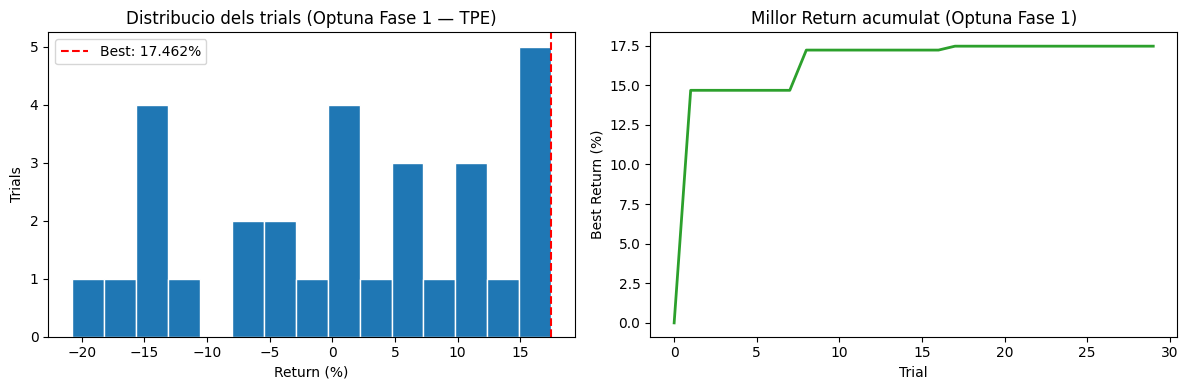

Guardat: results_sparse\05s_hrl_FeUdal_agent_relu_N\nb04_sparse_optuna_p1.png


In [27]:
# =============================================================================
# CEL·LA 13 — VISUALITZACIÓ OPTUNA FASE 1
# =============================================================================

trial_values = [t.value for t in study.trials
                if t.value is not None and np.isfinite(t.value)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(trial_values, bins=15, color='#1f77b4', edgecolor='white')
try:
    _bv = study.best_value
    axes[0].axvline(_bv, color='red', ls='--', label=f'Best: {_bv:.3f}%')
except ValueError:
    _bv = _best_val_p1  # fallback: valor del trial 0
    axes[0].axvline(_bv, color='orange', ls='--', label=f'Fallback trial-0: {_bv:.3f}%')
axes[0].set_xlabel('Return (%)'); axes[0].set_ylabel('Trials')
axes[0].set_title('Distribucio dels trials (Optuna Fase 1 — TPE)')
axes[0].legend()

best_so_far = [max(trial_values[:i+1]) for i in range(len(trial_values))]
axes[1].plot(best_so_far, color='#2ca02c', linewidth=2)
axes[1].set_xlabel('Trial'); axes[1].set_ylabel('Best Return (%)')
axes[1].set_title('Millor Return acumulat (Optuna Fase 1)')

plt.tight_layout()
plt.savefig(RESULTS / 'nb04_sparse_optuna_p1.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Guardat: {RESULTS / 'nb04_sparse_optuna_p1.png'}")


## 5b. Refinament Optuna Fase 2 (CMA-ES)

S'utilitza el millor resultat de Fase 1 com a punt de partida.
CMA-ES cerca en interval estret al voltant de `best_params_p1` (funcó `narrow`).
Variables categòriques (`n_steps`, `batch_size`, `c`, `goal_dim`, `N_layers`, `n_hidden`) es fixen.


In [28]:
# =============================================================================
# CEL·LA 14 — OPTUNA FASE 2: CMA-ES (refinament)
# =============================================================================
N_TRIALS_REFINE   = 5
# Recuperar best_params_p1 del JSON si el kernel s'ha reiniciat despres de la Fase 1
if 'best_params_p1' not in dir() or best_params_p1 is None:
    assert OPTUNA_HRL_P1_JSON.exists(), (
        f"best_params_p1 no disponible i no trobat a {OPTUNA_HRL_P1_JSON}.\n"
        "Executa primer la Fase 1 (cel·la 20)."
    )
    with open(OPTUNA_HRL_P1_JSON) as _f:
        best_params_p1 = json.load(_f)["best_params_p1"]
    print(f"best_params_p1 carregat de {OPTUNA_HRL_P1_JSON}")

FIXED_CATS = {k: best_params_p1[k]
              for k in ['n_steps', 'batch_size', 'c']
              if k in best_params_p1}



def make_refine_objective(df_tr, df_vl, fixed, prefix: str = 'CMA'):
    bp = best_params_p1
    def objective(trial: optuna.Trial) -> float:
        lr_lo,  lr_hi  = narrow(bp['learning_rate'], 1e-4, 5e-4, pct=0.10)
        mlr_lo, mlr_hi = narrow(bp['manager_lr'],    1e-4, 5e-4, pct=0.10)
        g_lo,   g_hi   = narrow(bp['gamma'],         0.98, 0.9995, pct=0.10)
        gl_lo,  gl_hi  = narrow(bp['gae_lambda'],    0.90, 0.99, pct=0.10)
        ec_lo,  ec_hi  = narrow(bp['ent_coef'],      0.02, 0.1, pct=0.10)
        hp_lo,  hp_hi  = narrow(bp['hold_penalty'],  -0.1, -1e-5, pct=0.10)

        cfg = {
            **fixed,
            'learning_rate': trial.suggest_float('learning_rate', lr_lo,  lr_hi,  log=True),
            'manager_lr':    trial.suggest_float('manager_lr',    mlr_lo, mlr_hi, log=True),
            'n_epochs':      FIXED_HP['n_epochs'],
            'gamma':         trial.suggest_float('gamma',         g_lo,   g_hi),
            'gae_lambda':    trial.suggest_float('gae_lambda',    gl_lo,  gl_hi),
            'clip_range':    FIXED_HP['clip_range'],
            'ent_coef':      trial.suggest_float('ent_coef',      ec_lo,  ec_hi),
            'hold_penalty':  trial.suggest_float('hold_penalty',  hp_lo,  hp_hi),
            'batch_size':    FIXED_HP['batch_size'],
            'vf_coef': FIXED_HP['vf_coef'], 'max_grad_norm': FIXED_HP['max_grad_norm'], 'manager_max_grad_norm': FIXED_HP['manager_max_grad_norm'], 'reward_scale': FIXED_HP['reward_scale'], 'std_max': FIXED_HP['std_max'], 'seed': SEED,
        }

        run_name = f'{prefix}_{trial.number:03d}'
        writer_t = SummaryWriter(log_dir=str(RUNS_DIR / 'optuna' / run_name))
        # Log hiperparametres a TensorBoard (text) + pantalla
        _log_hparams(writer_t, cfg, context=prefix, trial_id=trial.number)
        torch.manual_seed(SEED)
        agent_ = FeUdalAgent(
            obs_dim=OBS_DIM, action_dim=N_ACTIONS,
            z_dim=Z_DIM, g_dim=G_DIM, k_dim=K_DIM,
            manager_hidden=MANAGER_HIDDEN, worker_hidden=WORKER_HIDDEN,
            fmrnn_hidden=FMRNN_HIDDEN,
            value_hidden=VALUE_HIDDEN,
            perception_hidden=PERCEPTION_HIDDEN,
        ).to(DEVICE)
        opt_p_, opt_m_, opt_w_ = _make_optimizers(agent_, cfg['learning_rate'], cfg['manager_lr'])
        buf_ = HierarchicalRolloutBuffer(
            n_steps=cfg['n_steps'], obs_dim=OBS_DIM,
            latent_dim=Z_DIM, goal_dim=G_DIM,
            c=cfg['c'], device=DEVICE,
        )
        eval_cb_ = HrlEvalCallback(
            df_vl=df_vl, eval_freq=EVAL_FREQ, n_eval_eps=N_EVAL_EPS_TUNE,
            device=DEVICE, c=cfg['c'], seed=SEED, verbose=0,
            trial=trial, writer=writer_t,
            # Custom prune (NOU): pruna trials que no mostren senyals de convergir
            custom_prune_warmup=CUSTOM_PRUNE_WARMUP,
            custom_prune_min_ret=CUSTOM_PRUNE_MIN_RET,
            check_policy=CUSTOM_PRUNE_CHECK_POLICY,
            max_entropy=CUSTOM_PRUNE_MAX_ENTROPY,
            min_kl=CUSTOM_PRUNE_MIN_KL,
        )
        try:
            if PRE_TRAINING:
                _cfg_synth = {**cfg, 'alpha': 0.0}
                for _df_s, _steps_s in [
                    (df_synth_p1, PRE_TRAIN_PHASE1_STEPS),
                    (df_synth_p2, PRE_TRAIN_PHASE2_STEPS),
                    (df_synth_p3, PRE_TRAIN_PHASE3_STEPS),
                ]:
                    train_hrl_alternate(agent_, opt_p_, opt_m_, opt_w_, buf_,
                                        _df_s, _df_s, _steps_s, _cfg_synth,
                                        phase='pre_train', freeze_manager=False, freeze_worker=False,
                                        manager_reward_mode='alignment', callbacks=[], writer=writer_t)
                opt_p_, opt_m_, opt_w_ = _make_optimizers(
                    agent_, cfg['learning_rate'], cfg['manager_lr'],
                    cfg.get('weight_decay', 0.0))
            train_hrl_alternate(agent_, opt_p_, opt_m_, opt_w_, buf_,
                                df_tr, df_vl, TUNE_TIMESTEPS, cfg,
                                phase='pre_train', freeze_manager=False, freeze_worker=False,
                                manager_reward_mode='combined', callbacks=[eval_cb_], writer=writer_t)
        except optuna.TrialPruned:
            writer_t.close()
            raise
        m = evaluate_agent(agent_, df_vl, n_episodes=5, device=DEVICE,
                           c=cfg['c'], seed=SEED)
        if m['position_frac'] < MIN_POSITION_FRAC:
            writer_t.close()
            raise optuna.TrialPruned(f"position_frac={m['position_frac']:.1%}")
        writer_t.add_scalar('trial/final_return',   m['mean_return'],  trial.number)
        writer_t.add_scalar('trial/final_sharpe',   m['sharpe'],       trial.number)
        writer_t.add_scalar('trial/position_frac',  m['position_frac'],trial.number)
        writer_t.close()

        # Mateix objectiu configurable que Fase 1
        obj_value = _compute_optuna_objective(eval_cb_.history, OPTUNA_OBJECTIVE)

        # Registra hparams a la pestanya HParams de TensorBoard
        _log_hparams_final(
            writer_t, cfg,
            metrics={
                'final_return':    m['mean_return'],
                'final_sharpe':    m['sharpe'],
                'position_frac':   m['position_frac'],
                'optuna_objective': obj_value,
            },
        )
        writer_t.flush()

        print(f"  [Refine {trial.number:>3}] Return: {m['mean_return']:+.4f}%  "
              f"Obj({OPTUNA_OBJECTIVE})={obj_value:+.4f}")
        return obj_value

    return objective


_p2_db = f"sqlite:///{OPTUNA_STORAGE_DIR}/hrl_feudal_cmaes.db"
study_refine = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.CmaEsSampler(seed=SEED),
    study_name=f'hrl_feudal_{NB_TAG}_cmaes',
    storage=_p2_db,
    load_if_exists=True,  # reprendre si s'interromp
)
tracker_refine = EmissionsTracker(
    project_name='hrl_feudal_refine', output_dir=str(CODECARBON_DIR), log_level='error'
)
tracker_refine.start()

_completed_p2 = len([t for t in study_refine.trials if t.state.name == 'COMPLETE'])
_remaining_p2 = max(0, N_TRIALS_REFINE - _completed_p2)
print(f'Optuna Fase 2 (CMA-ES): {N_TRIALS_REFINE} trials x {TUNE_TIMESTEPS:,} ts')
print(f'  Completats: {_completed_p2} / {N_TRIALS_REFINE}  |  Restants: {_remaining_p2}')
if _remaining_p2 > 0:
    study_refine.optimize(
        make_refine_objective(df_train, df_val, FIXED_CATS),
        n_trials=_remaining_p2, show_progress_bar=True,
    )
else:
    print("  Fase 2 ja completada — carregant resultats del DB.")
emissions_refine = tracker_refine.stop()

# Seleccionar millors parametres (Fase 1 o 2)
try:
    p1_val = study.best_value
except ValueError:
    p1_val = _best_val_p1  # fallback: valor del trial 0 (cap trial complet)
valid_p2  = [t.value for t in study_refine.trials
             if t.value is not None and t.value > float('-inf')]
p2_val    = max(valid_p2) if valid_p2 else float('-inf')

if p2_val >= p1_val:
    best_params     = {**FIXED_CATS, **study_refine.best_params}
    best_source     = 'Fase 2 (CMA-ES)'
    best_val_return = p2_val
else:
    best_params     = best_params_p1
    best_source     = 'Fase 1 (TPE)'
    best_val_return = p1_val

print(f'\nFont millors parametres: {best_source}  (Obj {OPTUNA_OBJECTIVE}: {best_val_return:+.4f})')
print(f'Emissions refine: {emissions_refine * 1000:.2f} g CO2eq')
print('Best params finals:')
for k, v in best_params.items():
    print(f'  {k:<28}: {v}')

# Persistir best_params — recuperable si el kernel es reinicia
with open(OPTUNA_HRL_P2_JSON, 'w') as _f:
    json.dump({'best_params_p2': {**FIXED_CATS, **study_refine.best_params},
               'best_value': study_refine.best_value}, _f, indent=2)
with open(OPTUNA_HRL_FINAL_JSON, 'w') as _f:
    json.dump({'best_params': best_params, 'best_source': best_source,
               'best_val_return': best_val_return}, _f, indent=2)
print(f'  best_params desat: {OPTUNA_HRL_FINAL_JSON}')




Optuna Fase 2 (CMA-ES): 5 trials x 2,000,000 ts
  Completats: 0 / 5  |  Restants: 5


  0%|          | 0/5 [00:00<?, ?it/s]


[CMA] Trial 0 HIPERPARAMETRES:
  batch_size        : 256
  c                 : 12
  clip_range        : 0.200000
  ent_coef          : 0.029169
  gae_lambda        : 0.953879
  gamma             : 0.994274
  hold_penalty      : -0.038628
  learning_rate     : 1.986e-04
  manager_lr        : 3.168e-04
  manager_max_grad_norm: 5.000000
  max_grad_norm     : 0.500000
  n_epochs          : 10
  n_steps           : 1024
  reward_scale      : 0.500000
  seed              : 42
  std_max           : 0.000e+00
  vf_coef           : 0.500000



[pre_train]:   0%|          | 0/2000000 [00:00<?, ?step/s]

[Trial 0] Custom prune @1,750,000: recent_mean_ret=-12.477% < threshold=+0.500%

[CMA] Trial 1 HIPERPARAMETRES:
  batch_size        : 256
  c                 : 12
  clip_range        : 0.200000
  ent_coef          : 0.028320
  gae_lambda        : 0.963727
  gamma             : 0.991722
  hold_penalty      : -0.032745
  learning_rate     : 1.864e-04
  manager_lr        : 3.115e-04
  manager_max_grad_norm: 5.000000
  max_grad_norm     : 0.500000
  n_epochs          : 10
  n_steps           : 1024
  reward_scale      : 0.500000
  seed              : 42
  std_max           : 0.000e+00
  vf_coef           : 0.500000



...

[pre_train]:   0%|          | 0/2000000 [00:00<?, ?step/s]

[Trial 3] Custom prune @1,750,000: recent_mean_ret=-5.362% < threshold=+0.500%

[CMA] Trial 4 HIPERPARAMETRES:
  batch_size        : 256
  c                 : 12
  clip_range        : 0.200000
  ent_coef          : 0.031903
  gae_lambda        : 0.946281
  gamma             : 0.983894
  hold_penalty      : -0.039420
  learning_rate     : 2.019e-04
  manager_lr        : 3.065e-04
  manager_max_grad_norm: 5.000000
  max_grad_norm     : 0.500000
  n_epochs          : 10
  n_steps           : 1024
  reward_scale      : 0.500000
  seed              : 42
  std_max           : 0.000e+00
  vf_coef           : 0.500000



[pre_train]:   0%|          | 0/2000000 [00:00<?, ?step/s]

[Trial 4] Custom prune @1,750,000: recent_mean_ret=-11.175% < threshold=+0.500%

Font millors parametres: Fase 1 (TPE)  (Obj best_return: +17.4624)
Emissions refine: 345.03 g CO2eq
Best params finals:
  ph1_timesteps               : 150000
  n_alt_cycles                : 5
  cycle_timesteps             : 100000
  alpha_decay_h               : 2.3996221847077153
  align_coef                  : 0.06183959119171456
  c                           : 12
  learning_rate               : 0.00020467814295900338
  manager_lr                  : 0.0002908715158986693
  n_steps                     : 1024
  gamma                       : 0.9843674876551414
  gae_lambda                  : 0.9011826284146027
  ent_coef                    : 0.03132367805122471
  hold_penalty                : -0.03614140908086991


ValueError: Record does not exist.

## 6. Entrenament Final

Entrena l'agent definitiu amb els millors hiperparàmetres de Fase 1+2.
`HrlEvalCallback` selecciona el millor model sobre val durant l'entrenament.


In [ ]:
# =============================================================================
# CEL·LA 14b — BEST PARAMS (hardcoded — salta Optuna si ja s'han obtingut)
# =============================================================================
# Executa aquesta cel·la si best_params no esta definit (kernel net o Optuna
# saltada). Valors inicials raonables per provar sense Optuna:
# - alpha moderat (0.1) perquè el Worker rebi r_ext però mantingui la
#   component intrinseca del paper FuN
# - c=12 (horitzo mitja del Manager)
# - gamma alt per al long-term planning
# Sobreescriure amb els valors reals d'Optuna un cop estigui executada.

# Intentar carregar best_params del JSON de l'optimitzacio HRL si el kernel es reinicia
if "best_params" not in dir() or best_params is None:
    if OPTUNA_HRL_FINAL_JSON.exists():
        with open(OPTUNA_HRL_FINAL_JSON) as _f:
            _hrl_data = json.load(_f)
        best_params     = _hrl_data["best_params"]
        best_source     = _hrl_data.get("best_source", "JSON (carregat)")
        best_val_return = _hrl_data.get("best_val_return", float("nan"))
        print(f"best_params carregat de {OPTUNA_HRL_FINAL_JSON}")
    else:
        # Fallback: valors hardcoded raonable per provar sense Optuna
        best_source = "hardcoded (Optuna no executada)"
        best_val_return = float("nan")
if "best_params" not in dir():
    best_params = {
        "c":             12,
        "alpha":         0.1,                        # NOU: alpha blending
        "learning_rate": 3e-5,
        "manager_lr":    3e-5,
        "n_steps":       1024,
        "batch_size":    256,
        "n_epochs":      5,
        "gamma":         0.99,
        "gae_lambda":    0.95,
        "clip_range":    0.2,
        "ent_coef":      0.02,
        "hold_penalty":  -0.005,
        "vf_coef":       0.5,
        "max_grad_norm": 0.5,
        "manager_max_grad_norm": 5.0,
            "reward_scale":  0.5,
        "std_max":        0.0,
        "seed":          SEED,
        'ph1_timesteps': 200_000,
        'ph2_timesteps': 200_000,
        'n_alt_cycles': 20,
        'cycle_timesteps': 100_000,
        'alpha_decay_h': 3.0,
        'align_coef': 0.1,
    }
    print("best_params definit manualment (Optuna no executada)")
else:
    print("best_params ja definit per Optuna")

for k, v in best_params.items():
    print(f"  {k:<28}: {v}")


In [ ]:
# =============================================================================
# CEL·LA 15 — ENTRENAMENT FINAL
# =============================================================================
LOGS_DIR = RESULTS / "logs"; LOGS_DIR.mkdir(parents=True, exist_ok=True)

print('Config entrenament final (FeudalAgent):')
for k, v in best_params.items():
    print(f'  {k:<28}: {v}')
print(f"  {'Total timesteps':28s}: {FINAL_TIMESTEPS:,}")

torch.manual_seed(SEED)
agent_final = FeUdalAgent(
    obs_dim=OBS_DIM, action_dim=N_ACTIONS,
    z_dim=Z_DIM, g_dim=G_DIM, k_dim=K_DIM,
    manager_hidden=MANAGER_HIDDEN, worker_hidden=WORKER_HIDDEN,
).to(DEVICE)

_n_params_final = sum(p.numel() for p in agent_final.parameters())
print(f'\nFeudalAgent final:')
print(f'  z_dim      = {Z_DIM}')
print(f'  g_dim      = {G_DIM}')
print(f'  k_dim      = {K_DIM}')
print(f'  params     = {_n_params_final:,}')

# Architecture summary
from src.rl.model_summary import model_summary
print(f"\nPerception module:")
model_summary(agent_final.perception, input_size=(1, OBS_DIM))
print(f"\nManager module:")
model_summary(agent_final.manager, input_size=(1, Z_DIM))
print(f"\nWorker module:")
model_summary(agent_final.worker, input_data=[torch.zeros(1, Z_DIM, device=DEVICE), torch.zeros(1, G_DIM, device=DEVICE)])

opt_p_final, opt_m_final, opt_w_final = _make_optimizers(
    agent_final, best_params['learning_rate'], best_params['manager_lr'],
    weight_decay=best_params.get('weight_decay', 0.0),
)

buf_final = HierarchicalRolloutBuffer(
    n_steps=best_params['n_steps'], obs_dim=OBS_DIM,
    latent_dim=Z_DIM, goal_dim=G_DIM,
    c=best_params['c'], device=DEVICE,
)

final_cfg = dict(best_params)
final_cfg.update({'vf_coef': 0.5, 'max_grad_norm': 0.5, 'manager_max_grad_norm': 5.0, 'seed': SEED})

eval_cb_final = HrlEvalCallback(
    df_vl=df_val, eval_freq=EVAL_FREQ, n_eval_eps=N_EVAL_EPS,
    device=DEVICE, c=best_params['c'], seed=SEED, verbose=1,
)
fee_cb_final = FeeCurriculumCallback(
    total_timesteps=FINAL_TIMESTEPS, env_ref=[],  # env_ref injected by train_hrl
)

writer = SummaryWriter(log_dir=str(RUNS_DIR / 'hrl_feudal_sparse_final'))
print(f'TensorBoard: tensorboard --logdir {RUNS_DIR}')

# Log hiperparametres a TensorBoard (text tab, visible des del principi)
_log_hparams(writer, final_cfg, context='FINAL', trial_id=None)

tracker_final = EmissionsTracker(
    project_name='hrl_feudal_sparse_final', output_dir=str(CODECARBON_DIR), log_level='error'
)
tracker_final.start()
if PRE_TRAINING:
    _cfg_synth_f = {**final_cfg, 'alpha': 0.0}
    for _df_s, _steps_s in [
        (df_synth_p1, PRE_TRAIN_PHASE1_STEPS),
        (df_synth_p2, PRE_TRAIN_PHASE2_STEPS),
        (df_synth_p3, PRE_TRAIN_PHASE3_STEPS),
    ]:
        train_hrl_alternate(
                agent_final, opt_p_final, opt_m_final, opt_w_final, buf_final,
                _df_s, _df_s, _steps_s, _cfg_synth_f,
                phase='pre_train', freeze_manager=False, freeze_worker=False,
                manager_reward_mode='alignment', callbacks=[], writer=writer,
                global_step_ref=[0], verbose=False)
    opt_p_final, opt_m_final, opt_w_final = _make_optimizers(
        agent_final, final_cfg['learning_rate'], final_cfg['manager_lr'],
        final_cfg.get('weight_decay', 0.0))
    print('Pre-entrenament completat.')
# Fase 1: Manager Bootstrap
train_hrl_alternate(
    agent_final, opt_p_final, opt_m_final, opt_w_final, buf_final,
    df_train, df_val, final_cfg['ph1_timesteps'], final_cfg,
    phase='ph1_manager', freeze_manager=False, freeze_worker=True,
    manager_reward_mode='alignment', callbacks=[eval_cb_final, fee_cb_final],
    writer=writer, global_step_ref=[0], verbose=True,
    log_project='hrl_feudal_sparse_final', log_dir=LOGS_DIR
)

# Reset optimitzadors Ph1→Ph2 (moments Adam obsolets)
opt_p_final, opt_m_final, opt_w_final = _make_optimizers(
    agent_final, final_cfg['learning_rate'], final_cfg['manager_lr'],
    final_cfg.get('weight_decay', 0.0))

# Fase 2: Worker Bootstrap
train_hrl_alternate(
    agent_final, opt_p_final, opt_m_final, opt_w_final, buf_final,
    df_train, df_val, final_cfg['ph2_timesteps'], final_cfg,
    phase='ph2_worker', freeze_manager=True, freeze_worker=False,
    manager_reward_mode='alignment', callbacks=[eval_cb_final, fee_cb_final],
    writer=writer, global_step_ref=[0], verbose=True,
    log_project='hrl_feudal_sparse_final', log_dir=LOGS_DIR
)

# Reset optimitzadors Ph2→Ph3 (Perception ha canviat)
opt_p_final, opt_m_final, opt_w_final = _make_optimizers(
    agent_final, final_cfg['learning_rate'], final_cfg['manager_lr'],
    final_cfg.get('weight_decay', 0.0))

# Fase 3: Entrenament Alternat
for cycle in range(final_cfg['n_alt_cycles']):
    alpha_t = alpha_decay(cycle, ALPHA_DECAY_0, final_cfg['alpha_decay_h'])
    print("="*80)
    print(f"FASE 3 - CYCLE {cycle + 1}/{final_cfg['n_alt_cycles']} | Alpha = {alpha_t:.4f}")
    print("="*80)

    # Reset optimitzadors cada cicle (representació canvia entre 3a i 3b)
    opt_p_final, opt_m_final, opt_w_final = _make_optimizers(
        agent_final, final_cfg['learning_rate'], final_cfg['manager_lr'],
        final_cfg.get('weight_decay', 0.0))

    # 3a: Manager
    train_hrl_alternate(
        agent_final, opt_p_final, opt_m_final, opt_w_final, buf_final,
        df_train, df_val, final_cfg['cycle_timesteps'], final_cfg,
        phase='ph3_manager', freeze_manager=False, freeze_worker=True,
        manager_reward_mode='combined', alpha_decay_value=alpha_t,
        callbacks=[eval_cb_final, fee_cb_final], writer=writer,
        global_step_ref=[0], verbose=True,
        log_project='hrl_feudal_sparse_final', log_dir=LOGS_DIR
    )

    # Reset optimitzadors 3a→3b (Manager ha canviat goals)
    opt_p_final, opt_m_final, opt_w_final = _make_optimizers(
        agent_final, final_cfg['learning_rate'], final_cfg['manager_lr'],
        final_cfg.get('weight_decay', 0.0))

    # 3b: Worker
    train_hrl_alternate(
        agent_final, opt_p_final, opt_m_final, opt_w_final, buf_final,
        df_train, df_val, final_cfg['cycle_timesteps'], final_cfg,
        phase='ph3_worker', freeze_manager=True, freeze_worker=False,
        manager_reward_mode='alignment', callbacks=[eval_cb_final, fee_cb_final],
        writer=writer, global_step_ref=[0], verbose=True,
        log_project='hrl_feudal_sparse_final', log_dir=LOGS_DIR
    )

emissions_final = tracker_final.stop()
writer.close()

eval_history = eval_cb_final.history

# Restaurar millor model (per Return en val)
if eval_cb_final._best_state is not None:
    agent_final.load_state_dict(eval_cb_final._best_state)
    print(f'\nRestautat model amb millor Return (val): {eval_cb_final._best_return:+.4f}%')

# Desar checkpoint
ckpt_path = HRL_CKPT_DIR / 'hrl_feudal_best.pt'
torch.save({
    'model_state_dict': agent_final.state_dict(),
    'config':           final_cfg,
    'obs_dim':          OBS_DIM,
    'n_actions':        N_ACTIONS,
    'n_params':         _n_params_final,
    'eval_history':     eval_history,
}, ckpt_path)

print(f'Checkpoint desat: {ckpt_path}')
print(f'Emissions final:  {emissions_final * 1000:.2f} g CO2eq')
if eval_history:
    best_h = max(eval_history, key=lambda h: h['sharpe'])
    print(f"Millor (val): Sharpe={best_h['sharpe']:.4f} | "
          f"Ret={best_h['mean_return']:.2f}% | MaxDD={best_h['max_drawdown']:.2f}%")

In [ ]:
# =============================================================================
# CEL·LA 16 — CORBES D'ENTRENAMENT
# =============================================================================

if eval_history:
    ts_vals  = [h['timestep']    for h in eval_history]
    sh_vals  = [h['sharpe']      for h in eval_history]
    ret_vals = [h['mean_return'] for h in eval_history]
    dd_vals  = [h['max_drawdown']for h in eval_history]
    tr_vals  = [h['mean_trades'] for h in eval_history]

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    axes[0, 0].plot(ts_vals, sh_vals,  color='#2ca02c', linewidth=2)
    axes[0, 0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
    axes[0, 0].set_title('Sharpe ratio (val)'); axes[0, 0].set_xlabel('Timesteps')

    axes[0, 1].plot(ts_vals, ret_vals, color='#1f77b4', linewidth=2)
    axes[0, 1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
    axes[0, 1].set_title('Retorn mig (val, %)'); axes[0, 1].set_xlabel('Timesteps')

    axes[1, 0].plot(ts_vals, dd_vals,  color='#d62728', linewidth=2)
    axes[1, 0].set_title('Max Drawdown (val, %)'); axes[1, 0].set_xlabel('Timesteps')

    axes[1, 1].plot(ts_vals, tr_vals,  color='#ff7f0e', linewidth=2)
    axes[1, 1].set_title('Trades mig per episodi (val)'); axes[1, 1].set_xlabel('Timesteps')

    plt.suptitle(f'Entrenament FeudalAgent HRL — {FINAL_TIMESTEPS:,} ts', fontsize=13)
    plt.tight_layout()
    plt.savefig(RESULTS / 'nb04_sparse_training_curves.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f"Guardat: {RESULTS / 'nb04_sparse_training_curves.png'}")
else:
    print('Sense historial d\'avaluacio.')


## 7. Avaluació Walk-Forward sobre el Test Split

Protocol idèntic a NB03b:
- L'agent recorre el test split sequüencialment (sense overlap)
- Cada episodi comença on va acabar l'anterior
- L'agent mai ha vist dades del test durant l'entrenament ni el tuning


In [ ]:
# =============================================================================
# CEL·LA 17 — WALK-FORWARD TEST
# =============================================================================

print(f'Walk-forward sobre test split ({len(df_test):,} files)...')
wf_results = walk_forward_eval_hrl(
    agent_final, df_test, DEVICE,
    c=best_params['c'],
    ep_steps=MAX_EPISODE_STEPS,
    seed=SEED,
    log_project=PROJECT + '_test',
    log_dir=RESULTS,
)
m = wf_results['metrics']

print()
print('=' * 55)
print('  RESULTATS FeudalAgent — TEST SPLIT (walk-forward)')
print('=' * 55)
print(f"  Retorn total acumulat : {m['total_return']:>+10.2f} %")
print(f"  Sharpe ratio          : {m['sharpe']:>+10.4f}")
print(f"  Max drawdown          : {m['max_drawdown']:>10.2f} %")
print(f"  Episodis              : {m['n_episodes']:>10,}")
print(f"  Passos totals         : {m['n_steps']:>10,}")
print('  Distribucio accions:')
for act_name, pct in m['action_dist_pct'].items():
    bar = '#' * int(pct / 2)
    print(f'    {act_name:<6}: {pct:>6.2f} %  {bar}')
print('=' * 55)

p_arr = np.array(wf_results['prices'], dtype=np.float64)
if len(p_arr) > 0:
    bah = (p_arr[-1] / p_arr[0] - 1) * 100
    print(f'  Buy-and-Hold ref: {bah:>+8.2f}%')
    print(f'  Alpha vs B&H:     {m["total_return"] - bah:>+8.2f}%')


In [ ]:
# =============================================================================
# CEL·LA 18 — VISUALITZACIÓ WALK-FORWARD
# =============================================================================

eq   = np.array(wf_results['equities'])
pr   = np.array(wf_results['prices'])
ep_r = np.array(wf_results['ep_returns'])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Equity curve
axes[0, 0].plot(eq, color='#2ca02c', linewidth=0.8, alpha=0.9, label='FeudalAgent')
if len(pr) > 0:
    bh = INITIAL_BALANCE * pr / pr[0]
    axes[0, 0].plot(bh, color='gray', lw=0.8, ls='--', alpha=0.6, label='Buy & Hold')
axes[0, 0].axhline(INITIAL_BALANCE, color='black', lw=0.6, ls=':')
axes[0, 0].set_title('Equity Curve — Walk-Forward Test')
axes[0, 0].set_xlabel('Pas'); axes[0, 0].set_ylabel('Equity (USD)')
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

# Preus BTC
axes[0, 1].plot(pr, color='#1f77b4', linewidth=0.6, alpha=0.8)
axes[0, 1].set_title('Preus BTC/USD (test split)')
axes[0, 1].set_xlabel('Pas'); axes[0, 1].set_ylabel('Preu (USD)')
axes[0, 1].grid(alpha=0.3)

# Distribucio d'accions
act_d      = m['action_dist_pct']
colors_bar = ['#7f7f7f', '#2ca02c', '#d62728', '#ff7f0e']
bars       = axes[1, 0].bar(act_d.keys(), act_d.values(), color=colors_bar)
axes[1, 0].set_title('Distribucio d\'accions (test)')
axes[1, 0].set_ylabel('%'); axes[1, 0].set_ylim(0, 100)
for bar, val in zip(bars, act_d.values()):
    axes[1, 0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                    f'{val:.1f}%', ha='center', va='bottom', fontsize=11)

# Retorn per episodi
colors_ep = ['#2ca02c' if r >= 0 else '#d62728' for r in ep_r]
axes[1, 1].bar(range(len(ep_r)), ep_r, color=colors_ep, alpha=0.8)
axes[1, 1].axhline(0, color='black', linewidth=0.8)
axes[1, 1].set_title(f'Retorn per episodi (n={len(ep_r)})')
axes[1, 1].set_xlabel('Episodi'); axes[1, 1].set_ylabel('Retorn (%)')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.suptitle(
    f'FeudalAgent HRL — Walk-Forward | '
    f"Ret: {m['total_return']:+.2f}% | Sharpe: {m['sharpe']:.3f} | MaxDD: {m['max_drawdown']:.2f}%",
    fontsize=12,
)
plt.tight_layout()
plt.savefig(RESULTS / 'nb04_sparse_wf_equity_curve.png', dpi=120, bbox_inches='tight')
plt.show()

# Sequencia d'accions
actions    = wf_results['actions']
fig2, ax2  = plt.subplots(figsize=(10, 3))
colors_map = {0: '#7f7f7f', 1: '#2ca02c', 2: '#d62728', 3: '#ff7f0e'}
ax2.scatter(range(len(actions)), actions,
            c=[colors_map[a] for a in actions], s=1, alpha=0.3)
ax2.set_yticks([0, 1, 2, 3])
ax2.set_yticklabels(['HOLD', 'LONG', 'SHORT', 'CLOSE'])
ax2.set_title('Sequencia d\'accions (test split — FeudalAgent HRL)')
ax2.set_xlabel('Pas')
plt.tight_layout()
plt.savefig(RESULTS / 'nb04_sparse_action_dist.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Guardat: {RESULTS / 'nb04_sparse_wf_equity_curve.png'}")


In [ ]:
# =============================================================================
# CEL·LA 19 — DESAR MÈTRIQUES FINALS
# =============================================================================

# Fallbacks per si Optuna no s'ha executat en aquesta sessio
try:
    _study_val = study.best_value if "study" in dir() else None
except ValueError:
    _study_val = _best_val_p1 if "_best_val_p1" in dir() else None
_best_src  = best_source      if "best_source" in dir() else "manual (Optuna no executada)"
_best_ret  = float(best_val_return) if "best_val_return" in dir() else None
_em_opt    = float(emissions_optuna) if "emissions_optuna" in dir() else 0.0
_em_ref    = float(emissions_refine) if "emissions_refine" in dir() else 0.0
_em_fin    = float(emissions_final)  if "emissions_final"  in dir() else 0.0

_n_params_final = sum(p.numel() for p in agent_final.parameters())

results_dict = {
    'agent':     'HRL_FeUdal_Multiplicative_CustomPPO',
    'framework': 'PyTorch (from scratch)',
    'architecture': {
        'z_dim':          Z_DIM,
        'g_dim':          G_DIM,
        'k_dim':          K_DIM,
        'manager_hidden': MANAGER_HIDDEN,
        'worker_hidden':  WORKER_HIDDEN,
        'n_params':       _n_params_final,
        'note': 'Multiplicative goal integration: U·w policy in Worker',
    },
    'walk_forward': {
        'train_rows': len(df_train),
        'val_rows':   len(df_val),
        'test_rows':  len(df_test),
    },
    'optuna': {
        'n_trials':         N_TRIALS,
        'n_trials_refine':  N_TRIALS_REFINE,
        'tune_ts':          TUNE_TIMESTEPS,
        'best_return_p1':   _study_val,
        'best_source':      _best_src,
        'best_val_return':  _best_ret,
        'best_params':      best_params,
    },
    'training': {
        'final_timesteps': FINAL_TIMESTEPS,
        'config':          final_cfg,
    },
    'test_metrics':       wf_results['metrics'],
    'eval_history_final': eval_history,
    'sustainability': {
        'emissions_optuna_kg': _em_opt,
        'emissions_refine_kg': _em_ref,
        'emissions_final_kg':  _em_fin,
        'emissions_total_g':   (_em_opt + _em_ref + _em_fin) * 1000,
    },
}

out_path = RESULTS / 'nb04_sparse_hrl_feudal_metrics.json'
with open(out_path, 'w', encoding='utf-8') as fh:
    json.dump(results_dict, fh, indent=2, default=str, ensure_ascii=False)

print(f'Resultats desats: {out_path}')
print()
print('RESUM FINAL')
print('=' * 55)
print(f'  Agent:            FeudalAgent HRL Multiplicatiu')
print(f'  z_dim/g_dim/k_dim: {Z_DIM}/{G_DIM}/{K_DIM}')
print(f'  Params:           {_n_params_final:,}')
print(f'  Timesteps:        {FINAL_TIMESTEPS:,}')
print(f'  Optuna:           {N_TRIALS}+{N_TRIALS_REFINE} trials')
m = wf_results['metrics']
print(f'  Test retorn:      {m["total_return"]:+.2f}%')
print(f'  Test Sharpe:      {m["sharpe"]:.4f}')
print(f'  Test MaxDD:       {m["max_drawdown"]:.2f}%')
print(f'  CO2 total:        {results_dict["sustainability"]["emissions_total_g"]:.3f} g CO2eq')
print('=' * 55)
print('NB04-sparse completat')


## 8. Verificació: `src.FeudalAgent.load()` ≡ `agent_final`

Comprova que carregar el checkpoint des de `src/rl/agents/feudal_agent.py` dona resultats **numèricament idèntics** als obtinguts directament amb `agent_final` (cel·la anterior).

El `FeudalAgent` de `src/` és la còpia literal de la classe definida en aquest notebook, extreta perquè pugui ser importada des de qualsevol notebook d'avaluació o agent posterior sense redefinir-la in-line.


In [ ]:
# =============================================================================
# VERIFICACIÓ: src.FeudalAgent.load() ≡ agent_final
# =============================================================================
# Comprova que carregar el .pt des de src dona resultats idèntics
# a l'avaluació feta directament amb agent_final.
# =============================================================================

from src.rl.agents.feudal_agent import FeudalAgent as _FA_src

# ── Càrrega des de src ──────────────────────────────────────────────────────────
CKPT_PATH   = HRL_CKPT_DIR / 'hrl_feudal_best.pt'
agent_src   = _FA_src.load(CKPT_PATH, device=DEVICE)
params_src  = agent_src.count_params()
print(f'Carregat des de src: {params_src["total"]:,} params total')
print(f'  z_dim={agent_src.z_dim}  g_dim={agent_src.g_dim}  k_dim={agent_src.k_dim}')

# Verificació de pesos: han de ser idèntics als de agent_final
n_checked = 0
for key, w_orig in agent_final.state_dict().items():
    w_load = agent_src.state_dict()[key]
    assert torch.allclose(w_orig.cpu(), w_load.cpu()), f'Divergència en capa: {key}'
    n_checked += 1
print(f'Pesos idèntics a agent_final ({n_checked} tensors verificats) ✓')

# ── Walk-forward amb l'agent carregat des de src ────────────────────────────
print()
print('Walk-forward amb src.FeudalAgent.load() ...')
wf_src = walk_forward_eval_hrl(
    agent_src, df_test, DEVICE,
    c=best_params['c'],
    ep_steps=MAX_EPISODE_STEPS,
    seed=SEED,
    log_project=PROJECT + '_src_verify',
    log_dir=RESULTS,
)

# ── Comparació numèrica ─────────────────────────────────────────────────────────
m_orig = wf_results['metrics']
m_src  = wf_src['metrics']

print()
print(f"{'='*62}")
print(f"  {'Mètrica':<22} {'agent_final':>16} {'src.load()':>16}  OK")
print(f"  {'-'*60}")
for key in ['total_return', 'sharpe', 'max_drawdown', 'n_steps']:
    v1, v2 = m_orig[key], m_src[key]
    ok_sym = '✓' if abs(v1 - v2) < 1e-4 else '✗'
    print(f'  {key:<22} {v1:>+16.4f} {v2:>+16.4f}  {ok_sym}')
print(f"{'='*62}")

# Verifica accions idèntiques
acts_orig = wf_results['actions']
acts_src  = wf_src['actions']
if acts_orig == acts_src:
    print('Seqüència d\'accions idèntica ✓')
else:
    diff_count = sum(a != b for a, b in zip(acts_orig, acts_src))
    print(f'ATENCIÓ: {diff_count} accions difereixen (possible no-determinisme)')

print()
print('NB04b — Verificació src.FeudalAgent OK')
